# Stage 2 — Balanced-Sampling Fix, Full Training Grid & Evaluation

**Single entry-point notebook.** Every cell is **idempotent**: interrupt the kernel, restart, click **Run All**, and it picks up exactly where it left off (completed runs detected via `metrics.json`).

### Pipeline overview — priority order

**Phase 1 — Analysis deliverable (~15 min, all runs already completed)**
1. **Migrations** — resolve synthetic layout, link legacy checkpoints.
2. **Validation sanity-check** — Uniform 5× ResNet-18 (recovered).
3. **Tiny ImageNet ResNet-18 full grid** — all 8 pipelines (recovered).
4. **Tiny ImageNet MobileNetV3-Small** — 4 pipelines (recovered).
5. **FID** — read cached `fid_summary.json`.
6. **Figures** — 7 publication plots from `results/` → `figures/stage2/`.

**Phase 2 — CIFAR-100 + SA variants (runs unattended, ~5–8 h)**
7. **CIFAR-100 ResNet-18** — baseline (done) → uniform 15× → adaptive PU → ceiling.
8. **Synthetic-aware loss variants** — SA-loss versions on Tiny ImageNet + CIFAR-100.
9. **Final figures refresh** — regenerates all figures with CIFAR + SA results.

**Prerequisites:** Stage 1 subset, raw datasets, synthetic pools already generated under `data/synthetic/`.

In [1]:
# ============================================================
# 0.  Setup — imports, paths, reproducibility, master switches
# ============================================================
import os, sys, json, importlib, random
from pathlib import Path

import numpy as np
import torch

# ---- project root (notebook lives in notebooks/) ----
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# ---- reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- master switches (all True = full end-to-end) ----
RUN_MIGRATION          = True   # symlinks; never regenerates synthetic images
RUN_VALIDATION_CHECK   = True   # quick Uniform 5× R18 sanity test
RUN_TINY_R18           = True   # full Tiny ImageNet ResNet-18 grid (standard CE)
RUN_TINY_MOBILENET     = True   # Tiny ImageNet MobileNetV3-Small subset (standard CE)
RUN_CIFAR              = True   # CIFAR-100 ResNet-18 track (standard CE)
RUN_FID                = True   # global FID (reads cache first; only computes if missing)
RUN_FIGURES            = True   # summary plots from results/
RUN_SA_VARIANTS        = True   # SA loss runs included in this pass

print(f"Project root : {PROJECT_ROOT}")
print(f"CUDA         : {torch.cuda.is_available()}", end="")
if torch.cuda.is_available():
    print(f"  ({torch.cuda.get_device_name(0)})")
else:
    print("  (cpu)")

Project root : /mnt/data/cv
CUDA         : True  (NVIDIA GeForce RTX 4060 Ti)


## I. Orchestrator & helpers

Force-reload every `src.*` module that may have been edited between kernel restarts, then build the shared helpers used by every section below.

In [2]:
# ---- force-reload all src modules so on-disk fixes always take effect ----
_reload_order = [
    "src.models.backbone",
    "src.evaluation.eval_extras",
    "src.stage2.diagnostics",
    "src.training.synthetic_loss",
    "src.training.train_eval",
    "src.training.stage2_train",
    "src.evaluation.stage2_eval",
    "src.evaluation.fid_stage2",
    "src.data.synthetic_dataset",
    "src.data.registry",
    "src.allocation.policies",
    "src.stage2.orchestrator",
]
for _mn in _reload_order:
    if _mn in sys.modules:
        importlib.reload(sys.modules[_mn])

from src.stage2.orchestrator import Stage2Orchestrator
from src.config import load_experiment_config
from src.models.backbone import build_backbone
from src.evaluation.stage2_eval import evaluate_stage2
from src.data.registry import class_ids_in_label_order, get_baseline_loaders, build_real_train_subset
from src.data.transforms import get_train_transform, get_val_transform

orch = Stage2Orchestrator(PROJECT_ROOT)

# ---- idempotent run finder (shared by every section) ----
def find_completed_run(dataset: str, pipeline: str, arch: str) -> tuple:
    """Return (run_dir, metrics_dict) for the latest run that has metrics.json
    *and* the top5 field (added after initial runs).
    Returns (None, {}) if nothing completed yet.
    Returns (run_dir, {}) if best.pt exists but needs (re-)evaluation."""
    parent = PROJECT_ROOT / "results" / dataset / pipeline / arch
    if not parent.is_dir():
        return None, {}
    candidates = sorted(
        [d for d in parent.iterdir() if d.is_dir() and (d / "metrics.json").is_file()],
        key=lambda d: d.name,
    )
    if not candidates:
        # Fallback: best.pt exists but metrics.json missing → need re-eval
        partial = sorted(
            [d for d in parent.iterdir() if d.is_dir() and (d / "best.pt").is_file()],
            key=lambda d: d.name,
        )
        if partial:
            return partial[-1], {}  # caller should re-evaluate
        return None, {}
    rd = candidates[-1]
    m = json.loads((rd / "metrics.json").read_text(encoding="utf-8"))
    # Force re-eval if top5 was not computed (older runs)
    if "top5" not in m:
        return rd, {}
    return rd, m


def ensure_eval(rd: Path, arch: str, cfg_yaml: str, baseline_ckpt: Path = None) -> dict:
    """Re-evaluate a run that trained (best.pt) but has no/stale metrics.json."""
    cfg = load_experiment_config(orch.config_path(cfg_yaml), PROJECT_ROOT)
    tr_t = get_train_transform(cfg.dataset.image_size)
    va_t = get_val_transform(cfg.dataset.image_size)
    _, val_loader, c2i = get_baseline_loaders(cfg, tr_t, va_t)
    model = build_backbone(arch, cfg.dataset.num_classes)
    model.load_state_dict(torch.load(rd / "best.pt", map_location="cpu", weights_only=True))
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(dev)
    ref_cka = None
    if baseline_ckpt and baseline_ckpt.is_file():
        ref_cka = build_backbone(arch, cfg.dataset.num_classes)
        ref_cka.load_state_dict(torch.load(baseline_ckpt, map_location="cpu", weights_only=True))
        ref_cka.to(dev).eval()
    return evaluate_stage2(model, val_loader, cfg, c2i, dev, run_dir=rd, ref_model_for_cka=ref_cka)


def recover_or_train(dataset, pipeline, arch, train_fn, cfg_yaml="tiny_imagenet.yaml",
                     baseline_ckpt=None, label=None):
    """Idempotent wrapper: skip if completed, re-eval if partial/stale, else train."""
    tag = label or f"{dataset}/{pipeline}/{arch}"
    rd, m = find_completed_run(dataset, pipeline, arch)
    if rd and m:
        print(f"  ✓ {tag} recovered  top1={m['top1']:.4f}  top5={m.get('top5',0):.4f}")
        return rd, m
    if rd and not m:
        print(f"  ⟳ {tag} re-evaluating (top5 missing or no metrics) …")
        m = ensure_eval(rd, arch, cfg_yaml, baseline_ckpt)
        print(f"  ✓ {tag} top1={m['top1']:.4f}  top5={m.get('top5',0):.4f}")
        return rd, m
    print(f"  ▶ {tag} training …")
    rd, m = train_fn()
    print(f"  ✓ {tag} top1={m['top1']:.4f}  top5={m.get('top5',0):.4f}")
    return rd, m


print("Orchestrator ready. Device:", orch.device)

Orchestrator ready. Device: cuda


## II. Migrations

Resolves `data/synthetic_sd` → `data/synthetic/tiny_imagenet` and links Stage 1 checkpoints under `results/`. **Does not regenerate** any synthetic images.

In [3]:
if RUN_MIGRATION:
    synth_path = orch.migrate_tiny_synthetic()
    print("Synthetic (Tiny) resolved to:", synth_path)
    orch.link_stage1_checkpoints()
    print("Legacy checkpoints linked under results/…/legacy/")
else:
    print("Skipping migrations.")

Synthetic (Tiny) resolved to: /mnt/data/cv/data/synthetic_sd
Legacy checkpoints linked under results/…/legacy/


## III. Validation sanity-check — Uniform 5× ResNet-18

One quick run to confirm the balanced-sampling fix works. If top-1 ≥ 40 %, the real signal is no longer buried under synthetic data. If < 40 %, **stop** — the synthetic images themselves may be bad.

In [4]:
if RUN_VALIDATION_CHECK:
    # Look up baseline top-1 to set a relative threshold
    _bl_rd, _bl_m = find_completed_run("tiny_imagenet", "baseline", "resnet18")
    if _bl_rd and _bl_m:
        _bl_top1 = _bl_m.get("top1", 0.40)
        _threshold = _bl_top1 - 0.05
        print(f"  Baseline top1={_bl_top1:.4f} → validation threshold={_threshold:.4f}")
    else:
        _threshold = 0.35
        print(f"  No baseline found — using fallback threshold={_threshold:.4f}")

    rd, m = recover_or_train(
        "tiny_imagenet", "uniform_5x", "resnet18",
        train_fn=lambda: orch.train_uniform("tiny_imagenet.yaml", "resnet18", 5),
        cfg_yaml="tiny_imagenet.yaml",
        label="VALIDATION: uniform_5x / resnet18",
    )
    val_acc = m.get("top1", 0.0)
    print(f"\n{'='*60}")
    if val_acc >= _threshold:
        print(f"  ✅ Validation PASSED — top1 = {val_acc:.4f} (≥ {_threshold:.4f})")
    else:
        print(f"  ❌ Validation FAILED — top1 = {val_acc:.4f} (< {_threshold:.4f})")
        print("     Balanced-sampling fix may not be working, or synthetic images are bad.")
        print("     Investigate before proceeding.")
    print(f"{'='*60}\n")
else:
    print("Skipping validation check.")

  Baseline top1=0.4944 → validation threshold=0.4444
  ✓ VALIDATION: uniform_5x / resnet18 recovered  top1=0.5165  top5=0.7541

  ✅ Validation PASSED — top1 = 0.5165 (≥ 0.4444)



## IV. Tiny ImageNet — ResNet-18 full grid (standard CE)

Order: **baseline** → uniform 5×/10×/15× → diagnostics extraction → utility targets → allocation CSVs → adaptive (hard_class / uncertainty / predicted_utility) → **ceiling**.

All runs use **standard cross-entropy**. Synthetic-aware loss variants can be added later (see § X).
Results go to `results/tiny_imagenet/{pipeline}/resnet18/{timestamp}/`.

In [5]:
if not RUN_TINY_R18:
    print("Skipping Tiny ImageNet ResNet-18 grid.")
else:
    ARCH = "resnet18"
    CFG = "tiny_imagenet.yaml"
    DS = "tiny_imagenet"
    tiny_r18_runs = {}  # pipeline -> (run_dir, metrics)

    # ── 1. Baseline ──────────────────────────────────────────────
    print("─── Baseline ───")
    rd, m = recover_or_train(
        DS, "baseline", ARCH,
        train_fn=lambda: orch.train_baseline(CFG, ARCH),
        cfg_yaml=CFG,
    )
    tiny_r18_runs["baseline"] = (rd, m)
    r18_ckpt = Path(rd) / "best.pt"

    # ── 2. Uniform 5× / 10× / 15× (standard CE) ────────────────
    # baseline_ckpt_same_arch=None → forces ConcatDataset + standard CE
    # regardless of synthetic_aware_loss in the YAML.
    print("\n─── Uniform scaling (standard CE) ───")
    for ratio in [5, 10, 15]:
        _r = ratio  # capture for lambda
        rd, m = recover_or_train(
            DS, f"uniform_{ratio}x", ARCH,
            train_fn=lambda _r=_r: orch.train_uniform(
                CFG, ARCH, _r, baseline_ckpt_same_arch=None,
            ),
            cfg_yaml=CFG, baseline_ckpt=r18_ckpt,
        )
        tiny_r18_runs[f"uniform_{ratio}x"] = (rd, m)

    # ── 3. Diagnostics + utility targets + allocations ───────────
    print("\n─── Diagnostics & allocations ───")
    cfg_t = orch.load_cfg(CFG)
    tr_t = get_train_transform(cfg_t.dataset.image_size)
    va_t = get_val_transform(cfg_t.dataset.image_size)
    _, _, c2i = get_baseline_loaders(cfg_t, tr_t, va_t)
    cids = class_ids_in_label_order(c2i)

    # utility: compare baseline vs uniform-15x per-class accuracy
    mb = tiny_r18_runs["baseline"][1]
    mu = tiny_r18_runs["uniform_15x"][1]
    util_t = orch.utility_from_metrics(mb, mu, cids)
    utility_path_t = PROJECT_ROOT / "results" / DS / "utility_from_uniform15x.json"
    utility_path_t.parent.mkdir(parents=True, exist_ok=True)
    utility_path_t.write_text(json.dumps(util_t, indent=2), encoding="utf-8")
    print("  Saved utility targets →", utility_path_t)

    # diagnostics CSV from baseline checkpoint
    diag_csv = PROJECT_ROOT / "results" / DS / "diagnostics" / ARCH / "class_diagnostics.csv"
    if diag_csv.is_file():
        print("  Diagnostics CSV recovered →", diag_csv)
    else:
        diag_csv = orch.compute_baseline_diagnostics(CFG, r18_ckpt, arch=ARCH, quality_csv=None)
        print("  Diagnostics CSV →", diag_csv)

    # allocation CSVs
    alloc_dir = PROJECT_ROOT / "results" / DS / "allocations"
    needed_policies = ["hard_class", "uncertainty", "predicted_utility"]
    existing = [p for p in needed_policies if (alloc_dir / f"allocation_{p}.csv").is_file()]
    if set(existing) == set(needed_policies):
        print("  Allocation CSVs recovered →", alloc_dir)
    else:
        orch.build_allocations(
            CFG, diag_csv,
            utility_path_t if utility_path_t.exists() else None,
            policies=needed_policies,
        )
        print("  Allocation CSVs built →", alloc_dir)

    # ── 4. Adaptive (standard CE) ────────────────────────────────
    # baseline_ckpt_same_arch=None → standard CE for all three policies.
    print("\n─── Adaptive (standard CE) ───")
    for pol in needed_policies:
        csvp = alloc_dir / f"allocation_{pol}.csv"
        if not csvp.is_file():
            print(f"  ⚠ Missing allocation CSV for {pol}, skipping")
            continue
        pipe_name = f"adaptive_15x_{pol}"
        rd, m = recover_or_train(
            DS, pipe_name, ARCH,
            train_fn=lambda _c=csvp, _n=pipe_name: orch.train_adaptive(
                CFG, ARCH, _c, name=_n, baseline_ckpt_same_arch=None,
            ),
            cfg_yaml=CFG, baseline_ckpt=r18_ckpt,
        )
        tiny_r18_runs[pipe_name] = (rd, m)

    # ── 5. Ceiling (100 % real) ──────────────────────────────────
    print("\n─── Ceiling ───")
    rd, m = recover_or_train(
        DS, "ceiling", ARCH,
        train_fn=lambda: orch.train_ceiling(CFG, ARCH, baseline_ckpt_same_arch=None),
        cfg_yaml=CFG, baseline_ckpt=r18_ckpt,
    )
    tiny_r18_runs["ceiling"] = (rd, m)

    # ── 6. Full evaluation pass on any runs missing metrics.json ─
    print("\n─── Evaluation sweep ───")
    root_t = PROJECT_ROOT / "results" / DS
    for pipe_dir in sorted(root_t.iterdir()):
        if not pipe_dir.is_dir() or pipe_dir.name in ("diagnostics", "allocations", "legacy", "fid_cache"):
            continue
        arch_dir = pipe_dir / ARCH
        if not arch_dir.is_dir():
            continue
        for run in sorted(arch_dir.iterdir()):
            if not run.is_dir() or not (run / "best.pt").is_file():
                continue
            if (run / "metrics.json").is_file():
                continue
            print(f"  Re-evaluating {pipe_dir.name}/{ARCH}/{run.name} …")
            ensure_eval(run, ARCH, CFG, baseline_ckpt=r18_ckpt)
            print(f"    ✓ metrics.json written")

    # ── aggregate index ──────────────────────────────────────────
    orch.aggregate_results_index(CFG)
    print("\n✅ Tiny ImageNet ResNet-18 grid complete. Results index updated.")

─── Baseline ───
  ✓ tiny_imagenet/baseline/resnet18 recovered  top1=0.4944  top5=0.7559

─── Uniform scaling (standard CE) ───
  ✓ tiny_imagenet/uniform_5x/resnet18 recovered  top1=0.5165  top5=0.7541
  ✓ tiny_imagenet/uniform_10x/resnet18 recovered  top1=0.4998  top5=0.7456
  ✓ tiny_imagenet/uniform_15x/resnet18 recovered  top1=0.4985  top5=0.7572

─── Diagnostics & allocations ───
  Saved utility targets → /mnt/data/cv/results/tiny_imagenet/utility_from_uniform15x.json
  Diagnostics CSV recovered → /mnt/data/cv/results/tiny_imagenet/diagnostics/resnet18/class_diagnostics.csv
  Allocation CSVs recovered → /mnt/data/cv/results/tiny_imagenet/allocations

─── Adaptive (standard CE) ───
  ✓ tiny_imagenet/adaptive_15x_hard_class/resnet18 recovered  top1=0.4996  top5=0.7522
  ✓ tiny_imagenet/adaptive_15x_uncertainty/resnet18 recovered  top1=0.4999  top5=0.7521
  ✓ tiny_imagenet/adaptive_15x_predicted_utility/resnet18 recovered  top1=0.4929  top5=0.7490

─── Ceiling ───
  ✓ tiny_imagenet/ce

## V. Tiny ImageNet — MobileNetV3-Small

Subset of the grid: **baseline** → **uniform 15×** → **adaptive predicted_utility 15×** → **ceiling**.

In [6]:
if not RUN_TINY_MOBILENET:
    print("Skipping Tiny ImageNet MobileNetV3-Small.")
else:
    ARCH_M = "mobilenet_v3_small"
    CFG = "tiny_imagenet.yaml"
    DS = "tiny_imagenet"
    mob_runs = {}

    # ── Baseline ─────────────────────────────────────────────────
    print("─── Baseline ───")
    rd, m = recover_or_train(
        DS, "baseline", ARCH_M,
        train_fn=lambda: orch.train_baseline(CFG, ARCH_M),
        cfg_yaml=CFG,
    )
    mob_runs["baseline"] = (rd, m)
    mob_ckpt = Path(rd) / "best.pt"

    # ── Uniform 15× (standard CE) ────────────────────────────────
    print("\n─── Uniform 15× (standard CE) ───")
    rd, m = recover_or_train(
        DS, "uniform_15x", ARCH_M,
        train_fn=lambda: orch.train_uniform(
            CFG, ARCH_M, 15, baseline_ckpt_same_arch=None,
        ),
        cfg_yaml=CFG, baseline_ckpt=mob_ckpt,
    )
    mob_runs["uniform_15x"] = (rd, m)

    # ── Adaptive predicted_utility 15× (standard CE) ─────────────
    print("\n─── Adaptive predicted_utility (standard CE) ───")
    alloc_csv = PROJECT_ROOT / "results" / DS / "allocations" / "allocation_predicted_utility.csv"
    if alloc_csv.is_file():
        rd, m = recover_or_train(
            DS, "adaptive_15x_predicted_utility", ARCH_M,
            train_fn=lambda: orch.train_adaptive(
                CFG, ARCH_M, alloc_csv,
                name="adaptive_15x_predicted_utility",
                baseline_ckpt_same_arch=None,
            ),
            cfg_yaml=CFG, baseline_ckpt=mob_ckpt,
        )
        mob_runs["adaptive_15x_predicted_utility"] = (rd, m)
    else:
        print("  ⚠ Allocation CSV missing — run Tiny R18 grid first")

    # ── Ceiling ──────────────────────────────────────────────────
    print("\n─── Ceiling ───")
    rd, m = recover_or_train(
        DS, "ceiling", ARCH_M,
        train_fn=lambda: orch.train_ceiling(CFG, ARCH_M, baseline_ckpt_same_arch=None),
        cfg_yaml=CFG, baseline_ckpt=mob_ckpt,
    )
    mob_runs["ceiling"] = (rd, m)

    # ── Evaluation sweep ─────────────────────────────────────────
    print("\n─── Evaluation sweep ───")
    root_t = PROJECT_ROOT / "results" / DS
    for pipe_dir in sorted(root_t.iterdir()):
        if not pipe_dir.is_dir() or pipe_dir.name in ("diagnostics", "allocations", "legacy", "fid_cache"):
            continue
        arch_dir = pipe_dir / ARCH_M
        if not arch_dir.is_dir():
            continue
        for run in sorted(arch_dir.iterdir()):
            if not run.is_dir() or not (run / "best.pt").is_file():
                continue
            if (run / "metrics.json").is_file():
                continue
            print(f"  Re-evaluating {pipe_dir.name}/{ARCH_M}/{run.name} …")
            ensure_eval(run, ARCH_M, CFG, baseline_ckpt=mob_ckpt)
            print(f"    ✓ metrics.json written")

    orch.aggregate_results_index(CFG)
    print("\n✅ Tiny ImageNet MobileNetV3-Small complete. Results index updated.")

─── Baseline ───
  ✓ tiny_imagenet/baseline/mobilenet_v3_small recovered  top1=0.5031  top5=0.7769

─── Uniform 15× (standard CE) ───
  ✓ tiny_imagenet/uniform_15x/mobilenet_v3_small recovered  top1=0.5521  top5=0.7966

─── Adaptive predicted_utility (standard CE) ───
  ✓ tiny_imagenet/adaptive_15x_predicted_utility/mobilenet_v3_small recovered  top1=0.5503  top5=0.7984

─── Ceiling ───
  ✓ tiny_imagenet/ceiling/mobilenet_v3_small recovered  top1=0.7169  top5=0.9056

─── Evaluation sweep ───

✅ Tiny ImageNet MobileNetV3-Small complete. Results index updated.


## VI. FID — Global (cached)

Reads `results/{dataset}/fid_cache/fid_summary.json` if it exists. Only recomputes if the cache is missing. **Never regenerates** synthetic images.

In [7]:
if not RUN_FID:
    print("Skipping FID.")
else:
    for ds_name, yaml_name, ratios in [
        ("tiny_imagenet", "tiny_imagenet.yaml", [5, 10, 15]),
        ("cifar100", "cifar100.yaml", [15]),
    ]:
        cache_json = PROJECT_ROOT / "results" / ds_name / "fid_cache" / "fid_summary.json"
        if cache_json.is_file():
            fid_data = json.loads(cache_json.read_text(encoding="utf-8"))
            print(f"  {ds_name} FID (cached): {fid_data}")
        else:
            print(f"  {ds_name} FID cache not found — computing …")
            fid_data = orch.compute_global_fid(yaml_name, ratios=ratios)
            print(f"  {ds_name} FID: {fid_data}")

  tiny_imagenet FID (cached): {'fid_5x': 140.04724977469834, 'fid_10x': 139.60714257869586, 'fid_15x': 139.47715362344053}
  cifar100 FID (cached): {'fid_15x': 76.6385727349471}


## VII. Figures — Phase 1 deliverable

Reads `results/*/results_index.json` and writes comparison plots to `figures/stage2/` (PNG + PDF). At this point only Tiny ImageNet data is available; CIFAR-100 and SA results are added after Phase 2.

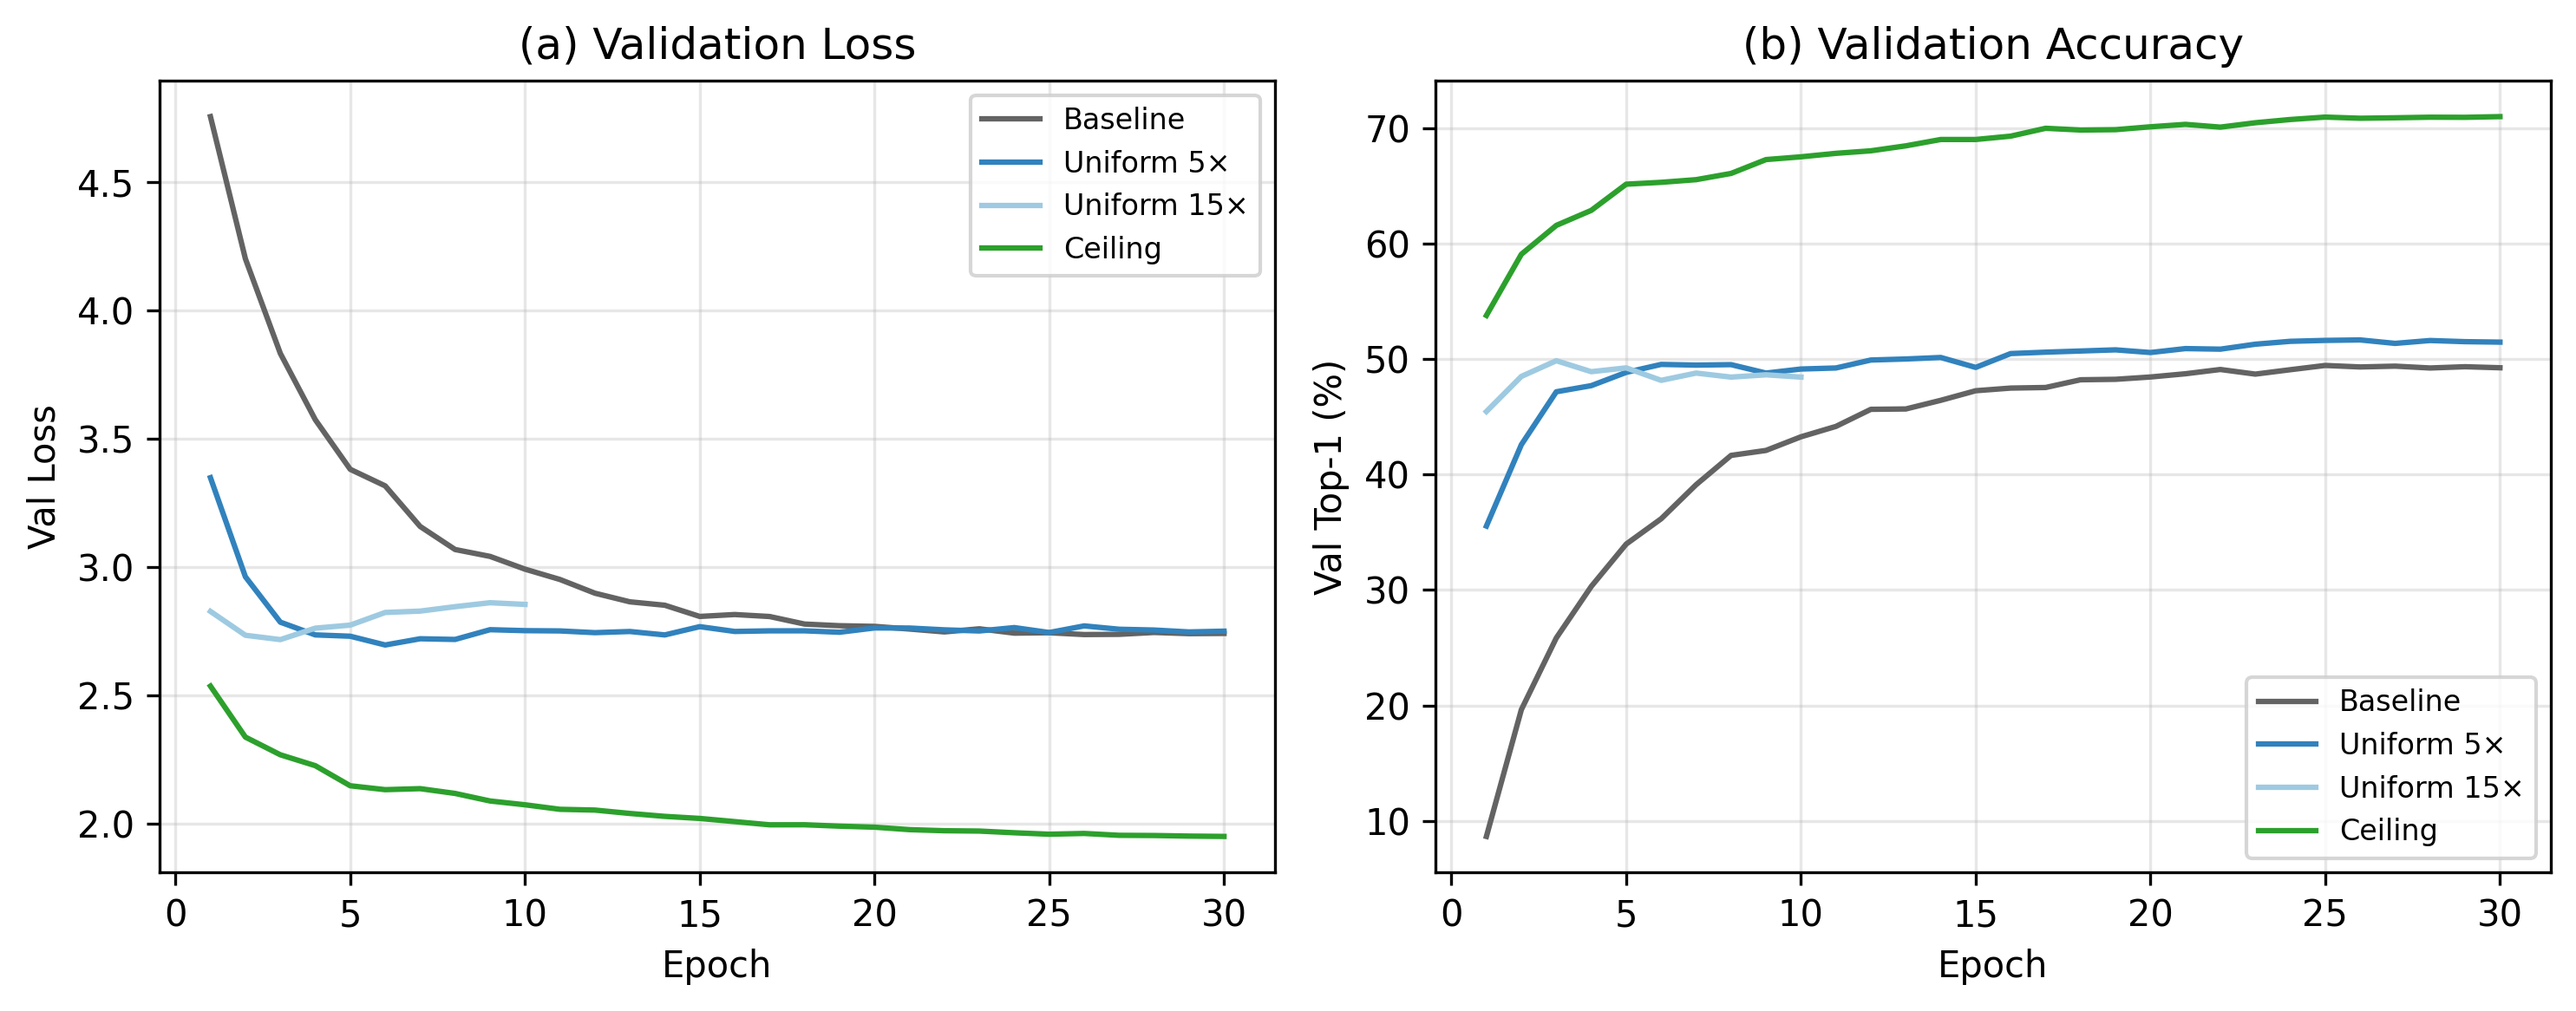

  ✓ fig1_learning_curves


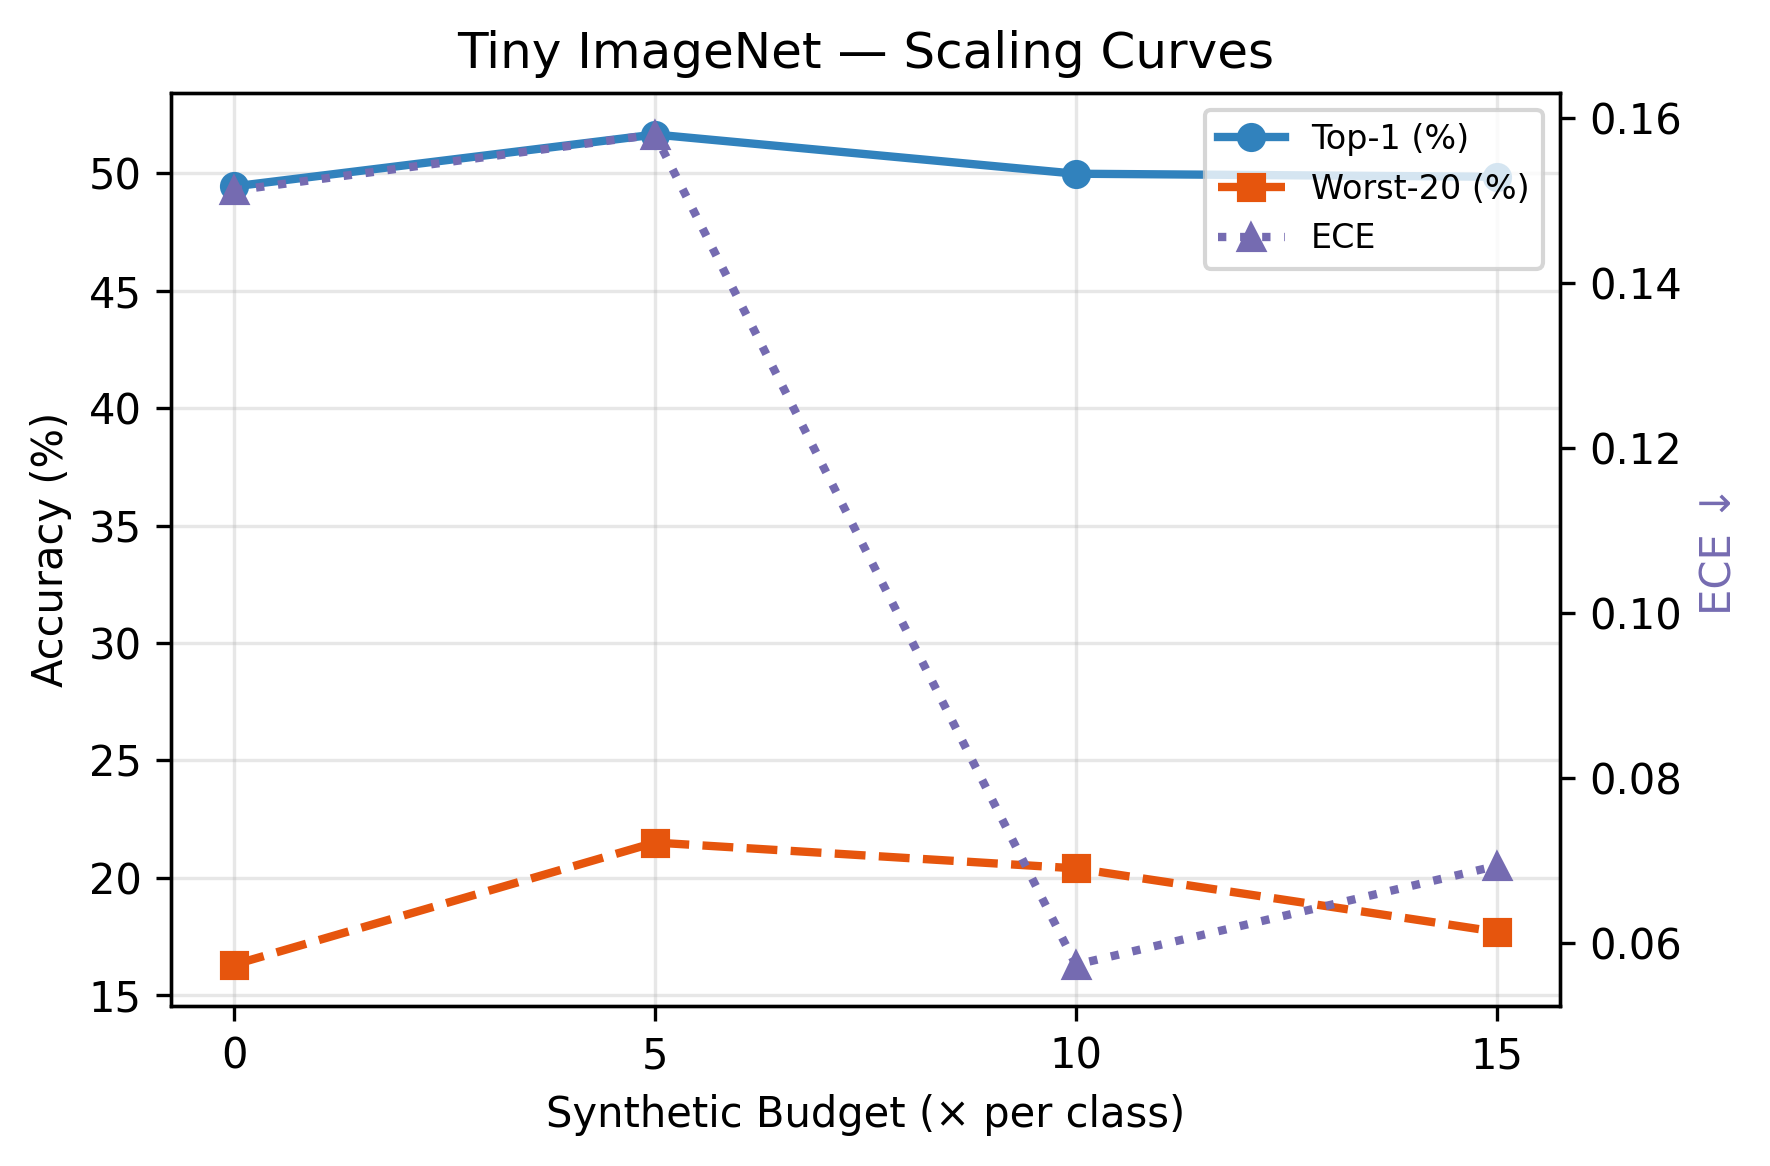

  ✓ fig2_scaling_curves


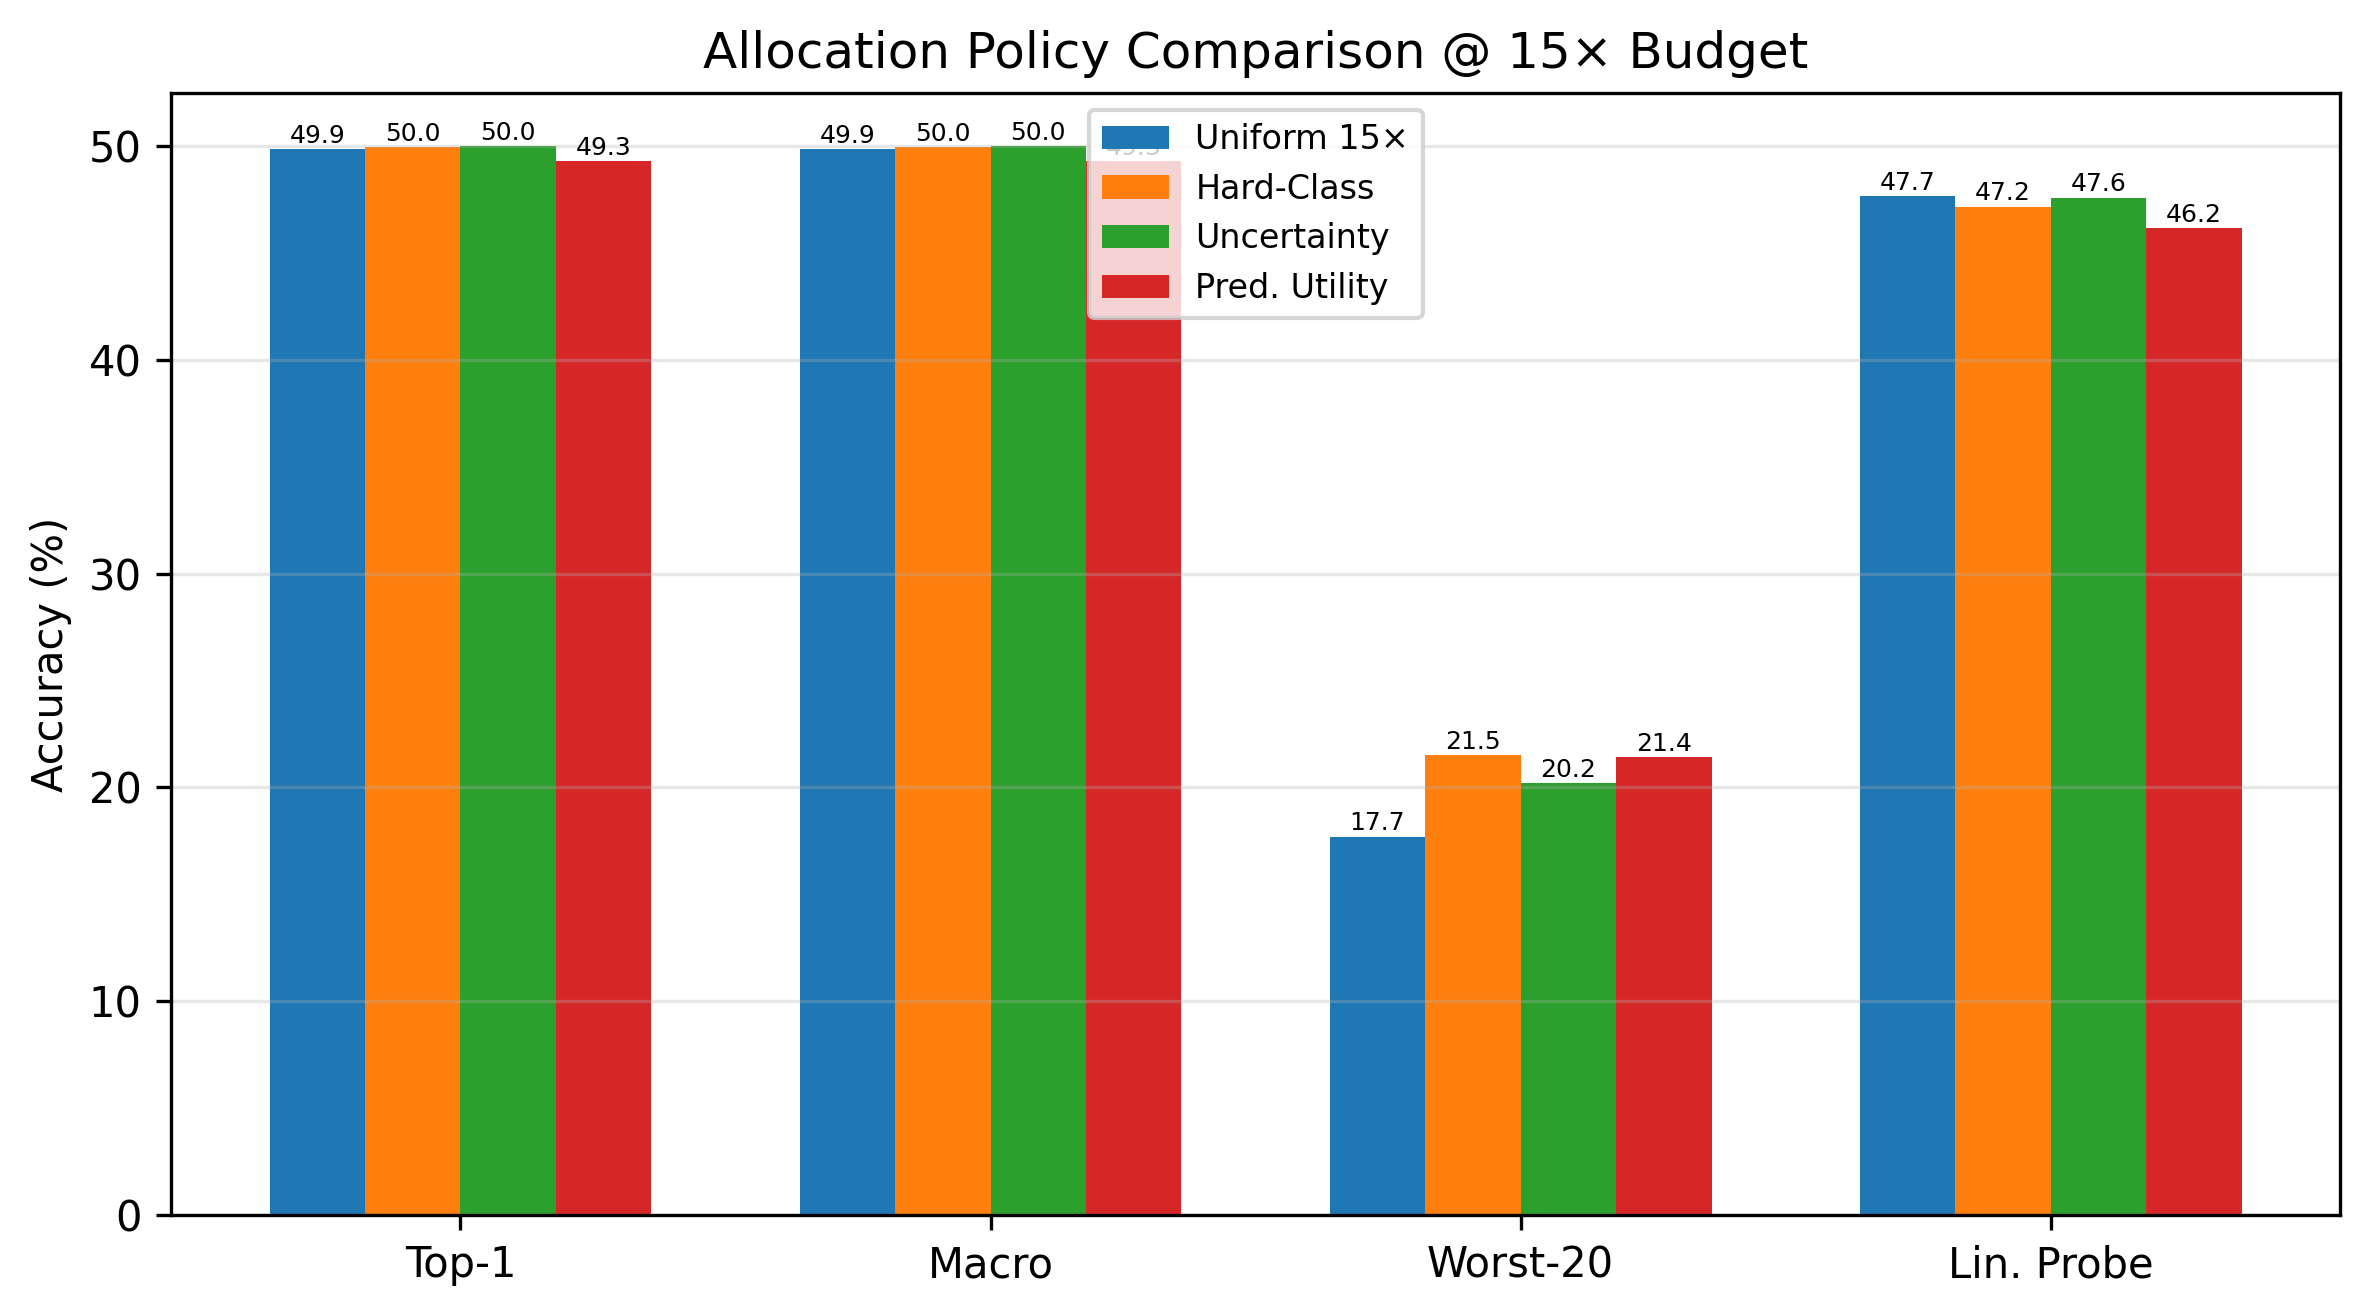

  ✓ fig3_policy_comparison


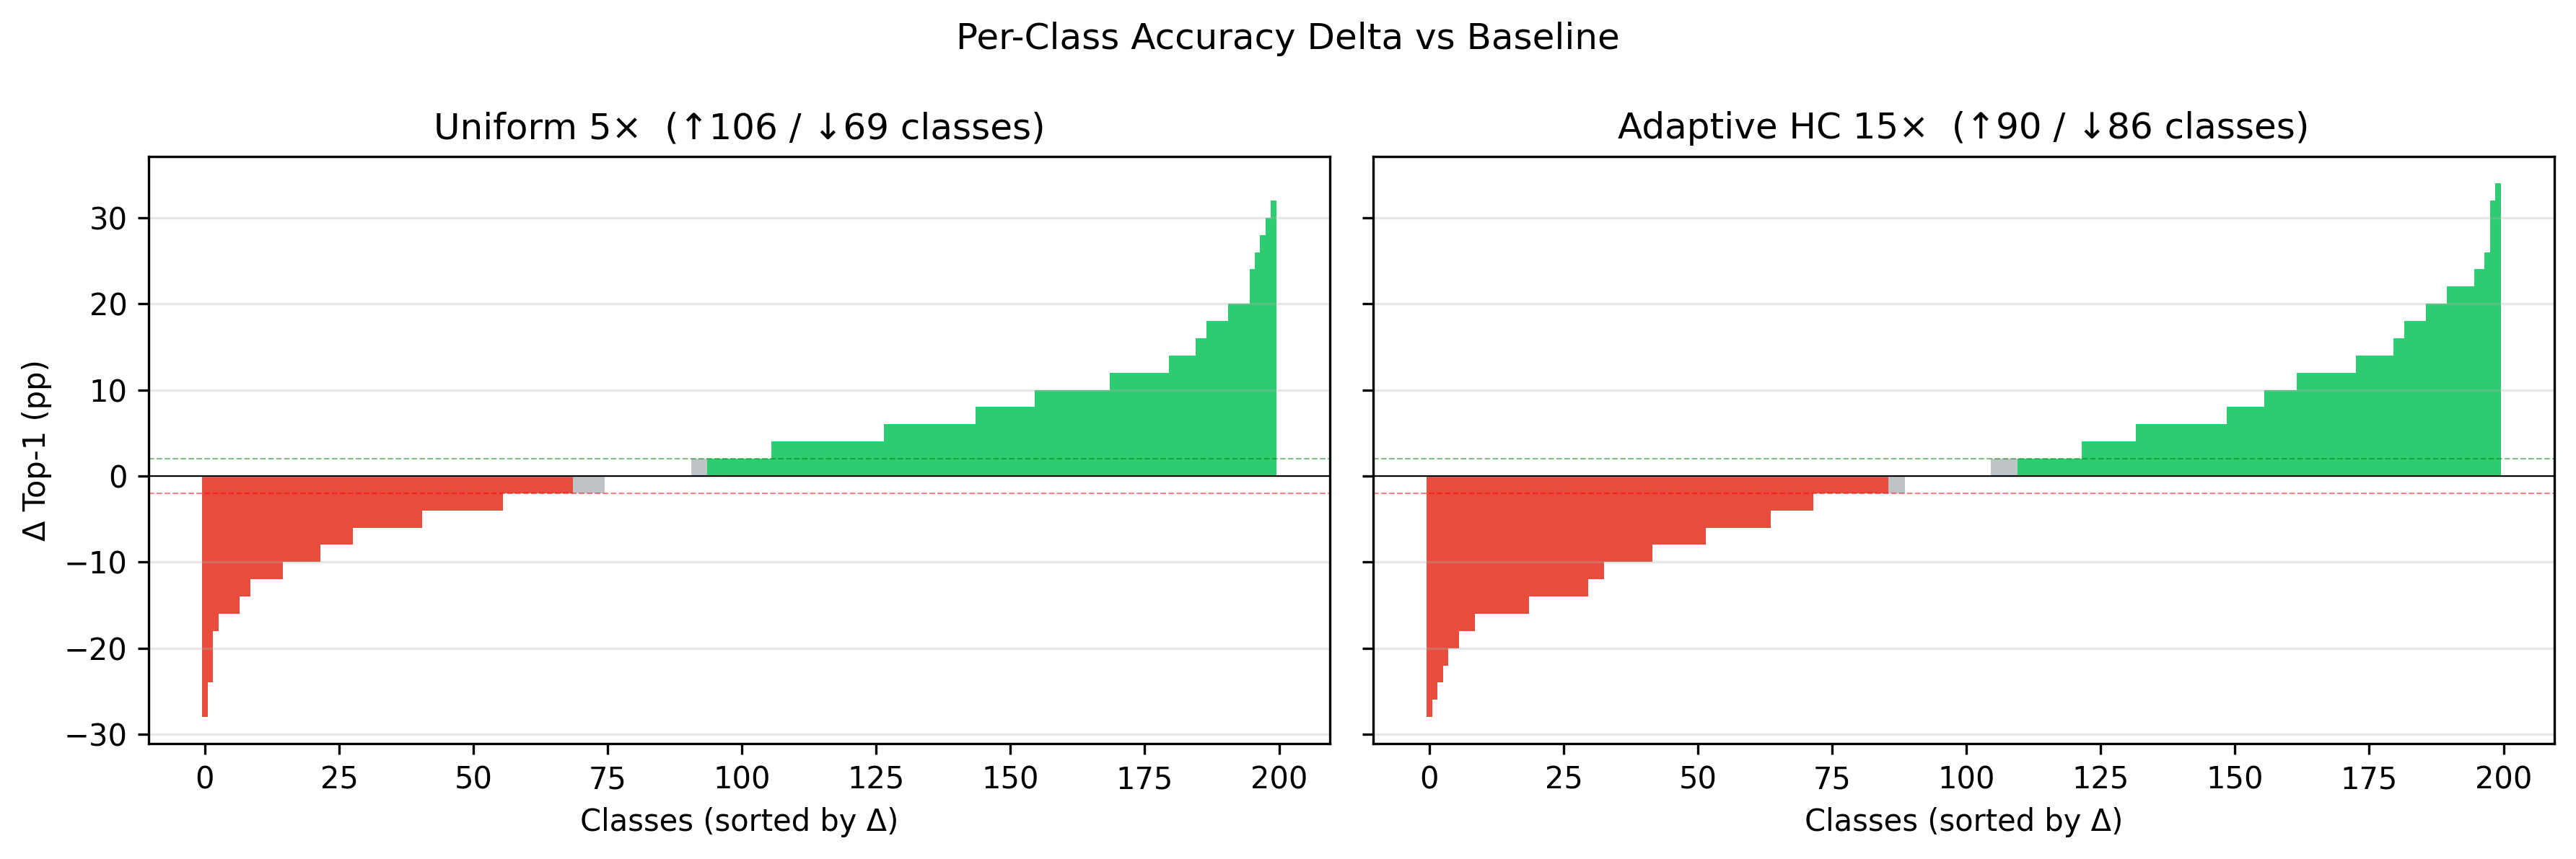

  ✓ fig4_perclass_delta


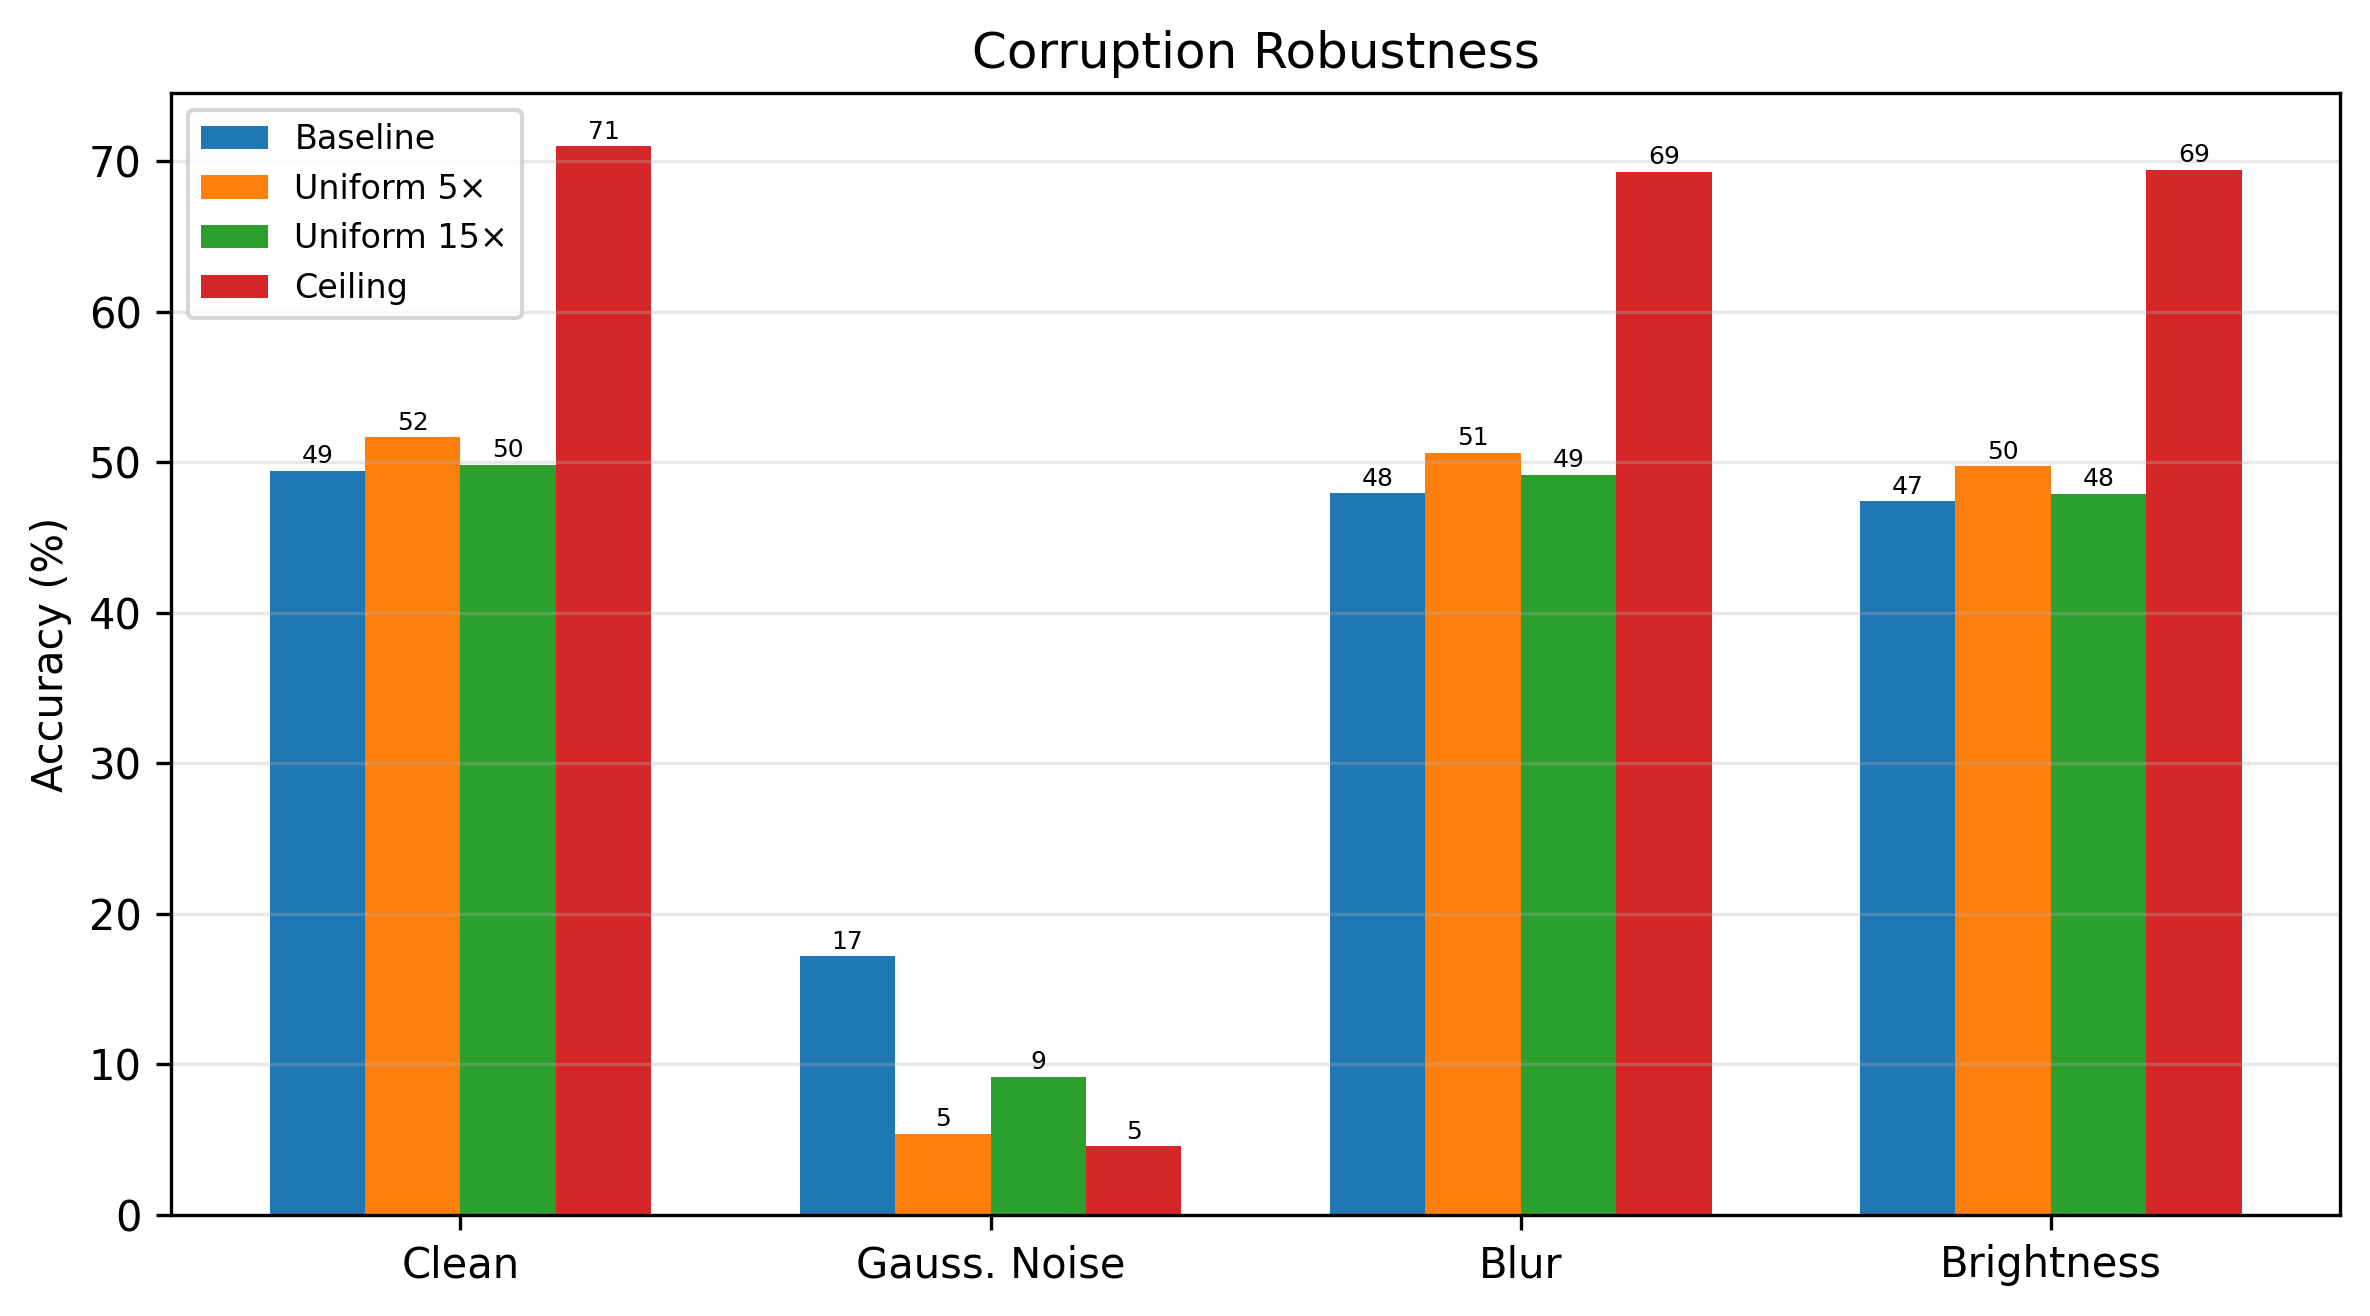

  ✓ fig5_corruption_robustness


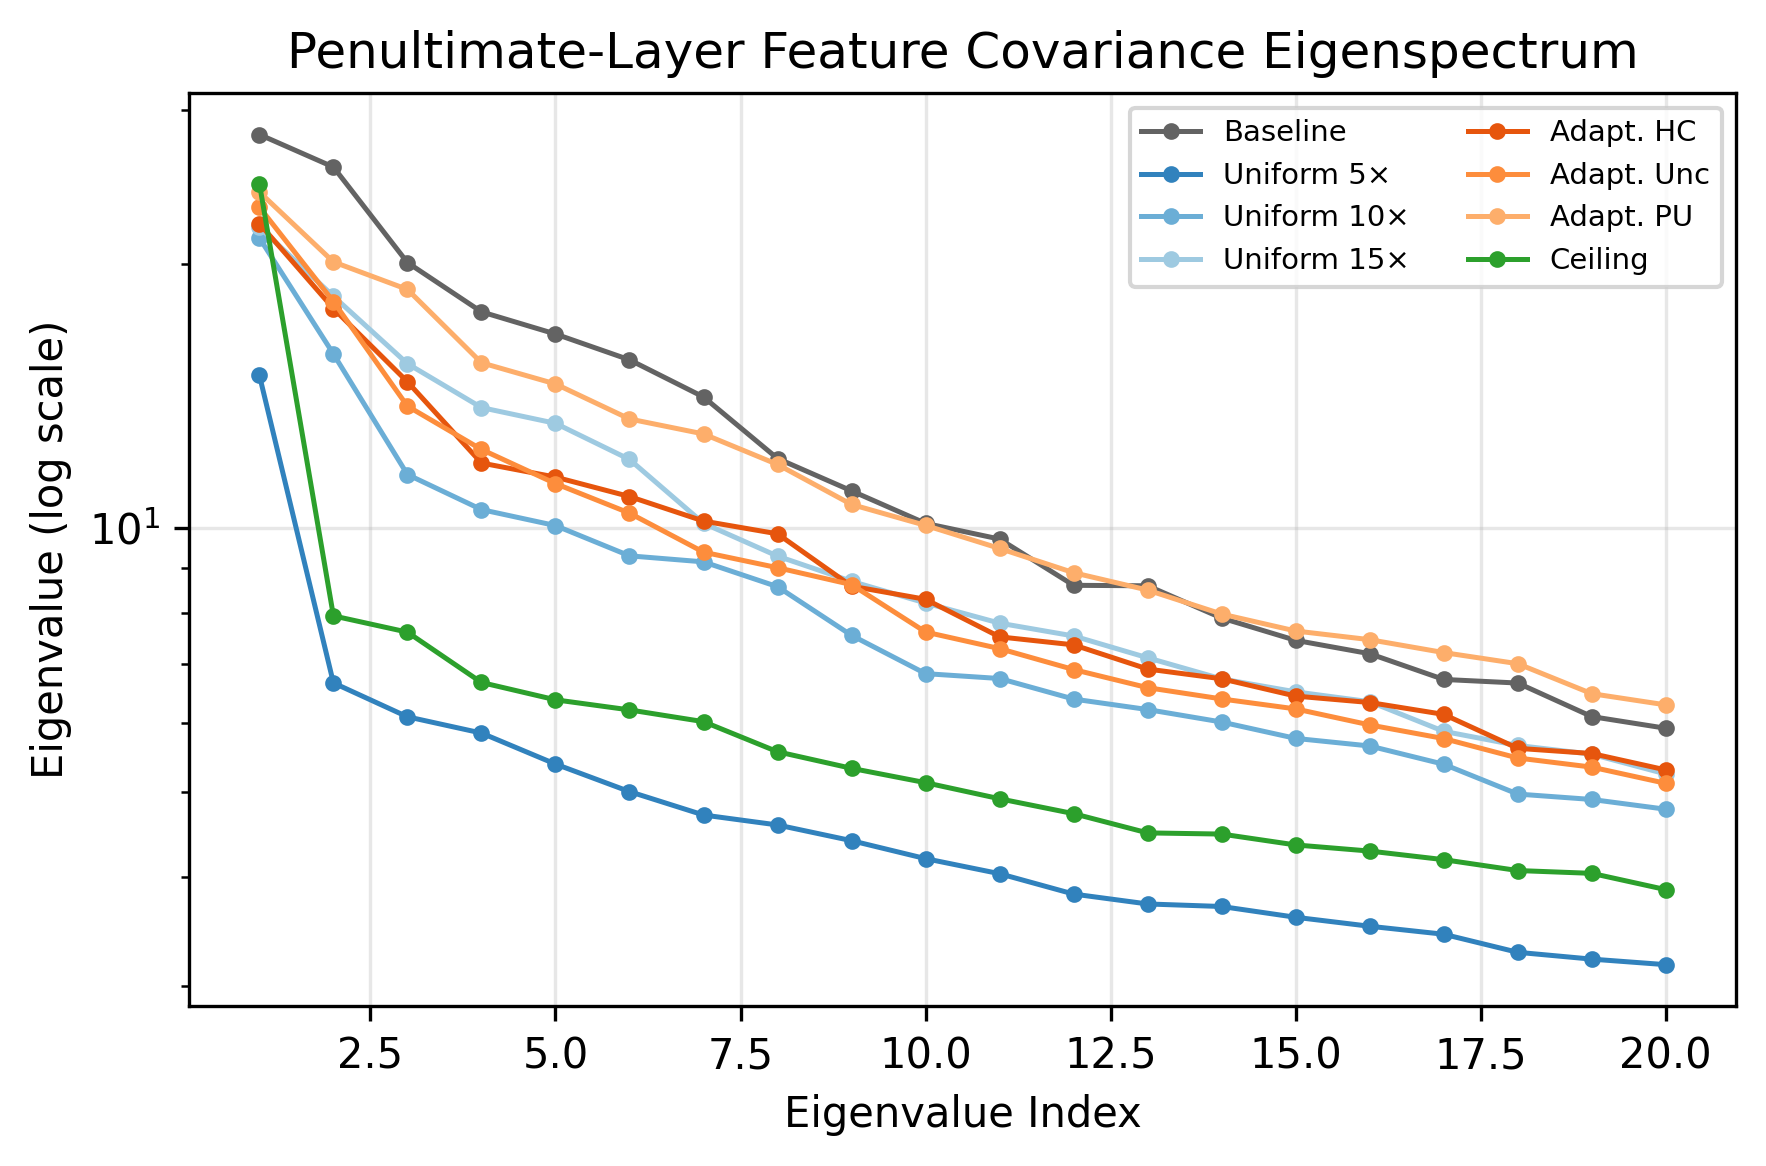

  ✓ fig6_eigenvalue_spectrum


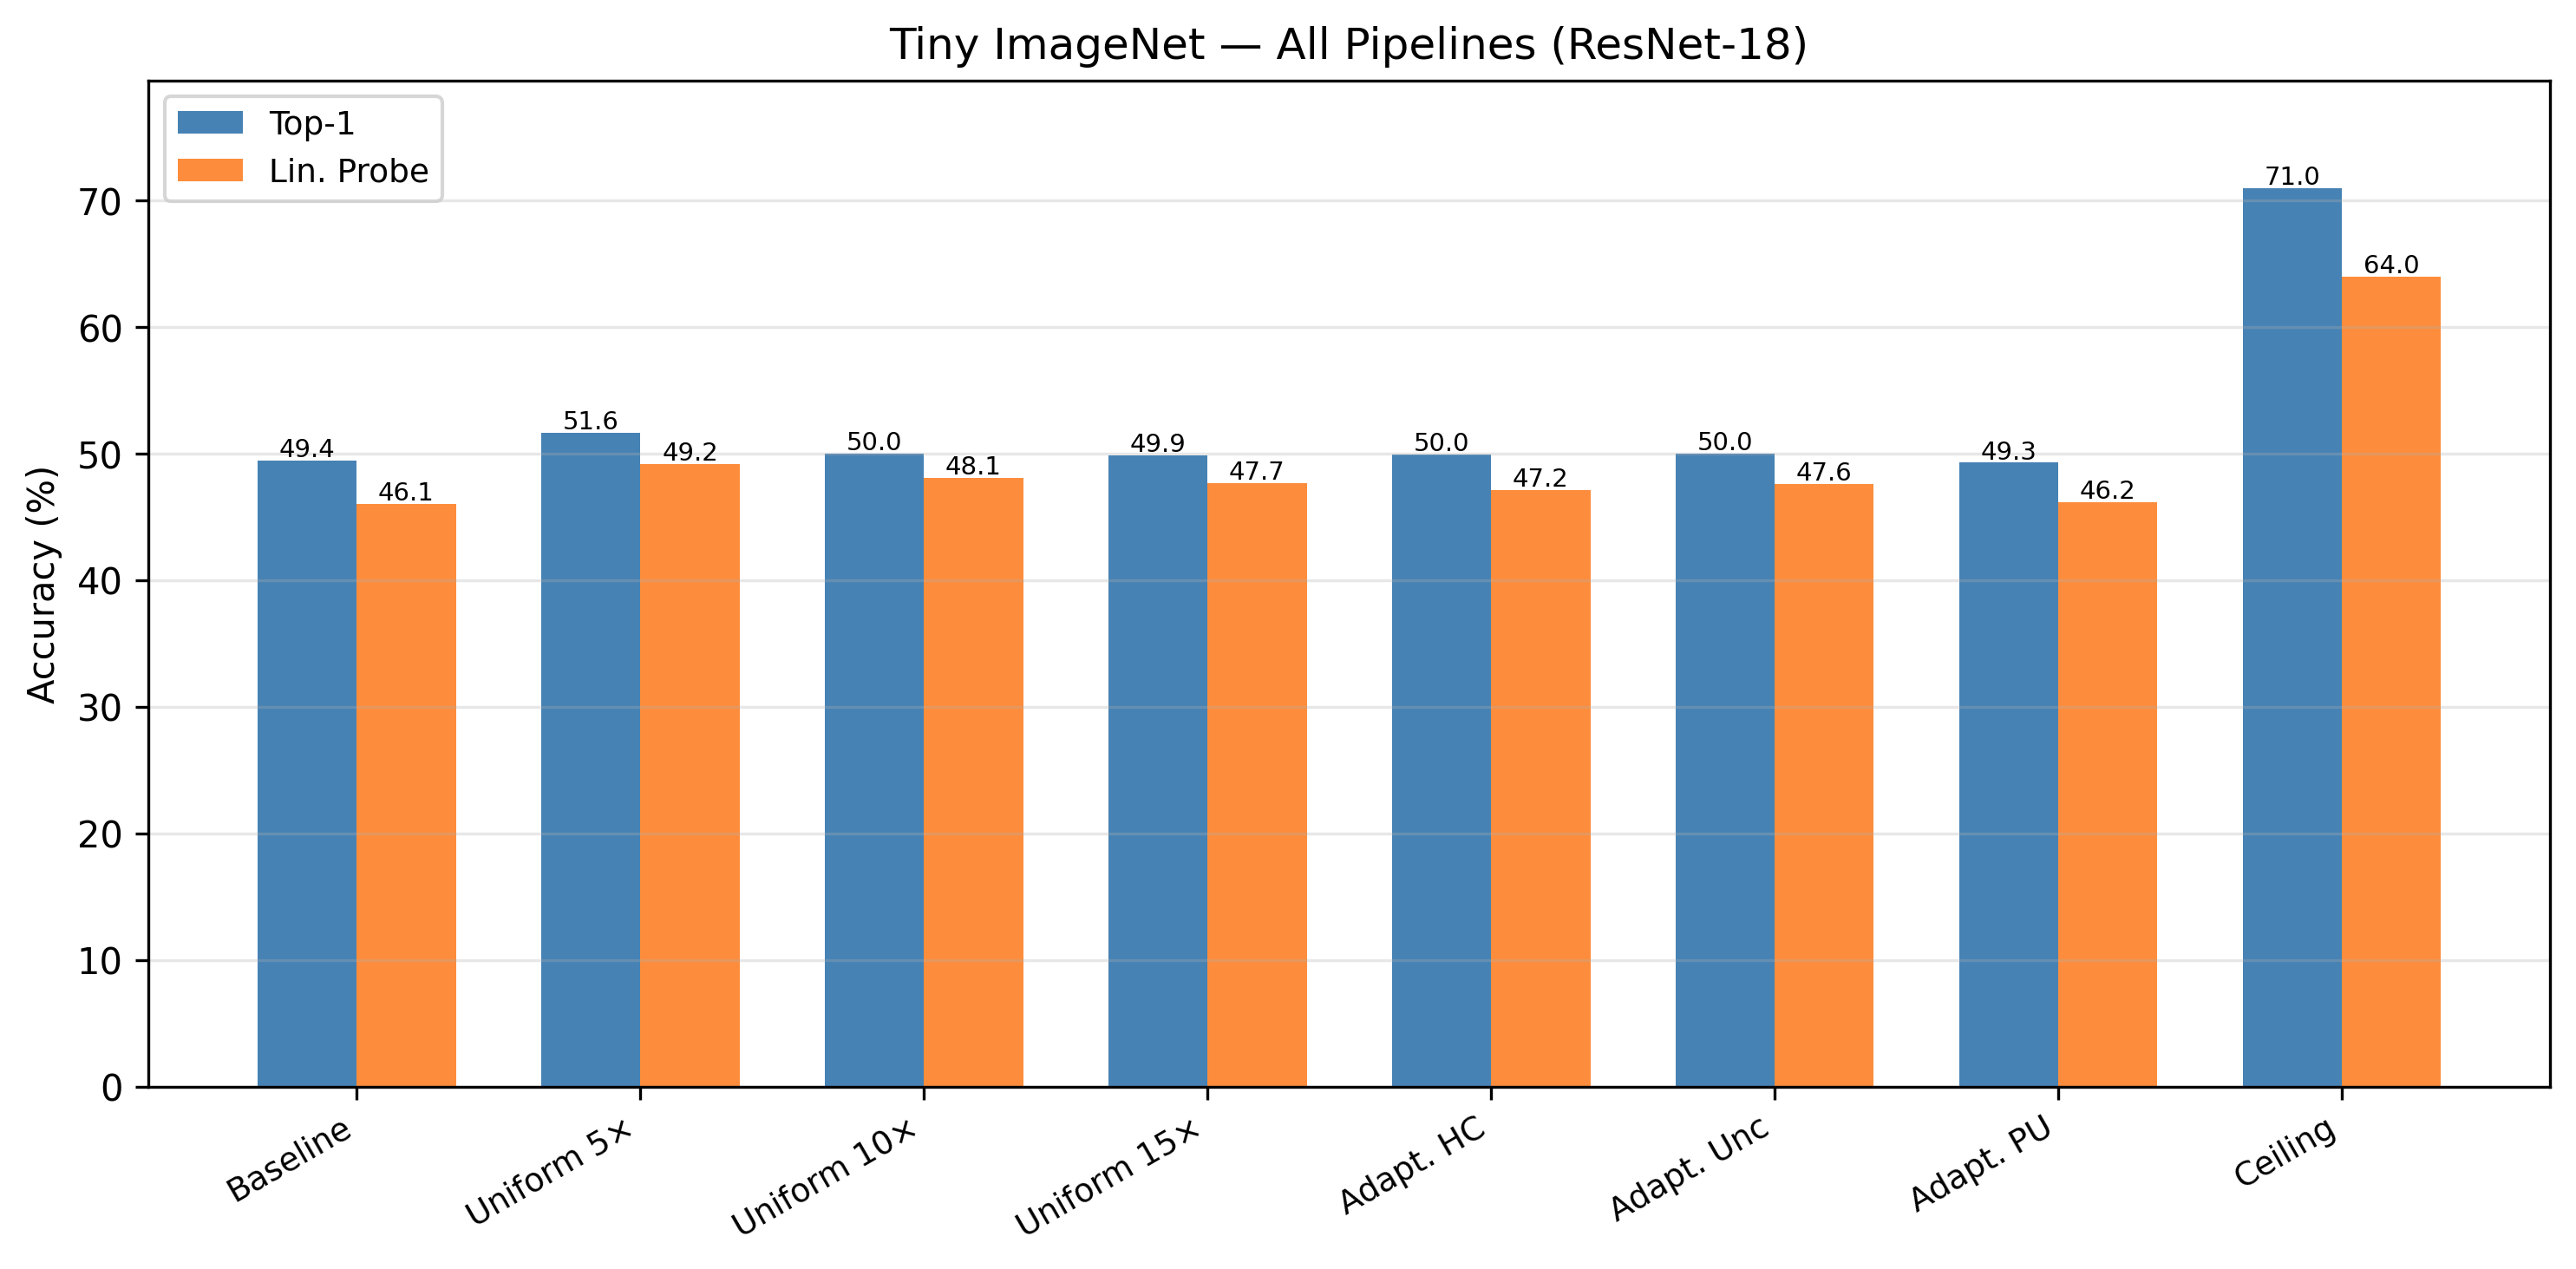

  ✓ fig7_summary_top1

PHASE 1 SUMMARY TABLE — Tiny ImageNet

  tiny_imagenet
  Pipeline                                 Arch                      Top-1
  ---------------------------------------- ---------------------- --------
  adaptive_15x_hard_class                  resnet18                 49.96%
  adaptive_15x_predicted_utility           mobilenet_v3_small       55.03%
  adaptive_15x_predicted_utility           resnet18                 49.29%
  adaptive_15x_uncertainty                 resnet18                 49.99%
  baseline                                 mobilenet_v3_small       50.31%
  baseline                                 resnet18                 49.44%
  ceiling                                  mobilenet_v3_small       71.69%
  ceiling                                  resnet18                 70.99%
  uniform_10x                              resnet18                 49.98%
  uniform_15x                              mobilenet_v3_small       55.21%
  uniform_15x         

In [8]:
if not RUN_FIGURES:
    print("Skipping figures.")
else:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    from IPython.display import display, Image as IPImage

    fig_dir = PROJECT_ROOT / "figures" / "stage2"
    fig_dir.mkdir(parents=True, exist_ok=True)

    # ── Helpers ──────────────────────────────────────────────────
    def _load_runs(ds="tiny_imagenet"):
        idx = PROJECT_ROOT / "results" / ds / "results_index.json"
        if not idx.is_file(): return {}
        rows = json.loads(idx.read_text(encoding="utf-8"))
        best = {}
        for r in rows:
            best[(r["pipeline"], r["arch"])] = r
        return best

    def _metrics(row):
        p = Path(row["path"]) / "metrics.json"
        return json.loads(p.read_text()) if p.is_file() else None

    def _curves(row):
        p = Path(row["path"]) / "training_curves.json"
        return json.loads(p.read_text()) if p.is_file() else None

    runs = _load_runs("tiny_imagenet")
    A = "resnet18"

    PIPES = ["baseline","uniform_5x","uniform_10x","uniform_15x",
             "adaptive_15x_hard_class","adaptive_15x_uncertainty",
             "adaptive_15x_predicted_utility","ceiling"]
    LABELS = ["Baseline","Uniform 5×","Uniform 10×","Uniform 15×",
              "Adapt. HC","Adapt. Unc","Adapt. PU","Ceiling"]
    COLORS = ["#636363","#3182bd","#6baed6","#9ecae1",
              "#e6550d","#fd8d3c","#fdae6b","#2ca02c"]

    def _save(name):
        png_path = fig_dir / f"{name}.png"
        plt.savefig(png_path, dpi=300, bbox_inches="tight")
        plt.savefig(fig_dir / f"{name}.pdf", bbox_inches="tight")
        plt.close()
        display(IPImage(filename=str(png_path)))
        print(f"  ✓ {name}")

    # ════════════════════════════════════════════════════════════
    # Fig 1 — Learning curves (val loss + val accuracy, 4 key pipelines)
    # ════════════════════════════════════════════════════════════
    _p1 = ["baseline","uniform_5x","uniform_15x","ceiling"]
    _l1 = ["Baseline","Uniform 5×","Uniform 15×","Ceiling"]
    _c1 = ["#636363","#3182bd","#9ecae1","#2ca02c"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for pipe, lbl, col in zip(_p1, _l1, _c1):
        k = (pipe, A)
        if k not in runs: continue
        tc = _curves(runs[k])
        if tc is None: continue
        ep = list(range(1, len(tc["val_loss"])+1))
        axes[0].plot(ep, tc["val_loss"], label=lbl, color=col, lw=1.5)
        axes[1].plot(ep, [v*100 for v in tc["val_acc"]], label=lbl, color=col, lw=1.5)
    axes[0].set(xlabel="Epoch", ylabel="Val Loss", title="(a) Validation Loss")
    axes[1].set(xlabel="Epoch", ylabel="Val Top-1 (%)", title="(b) Validation Accuracy")
    for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    _save("fig1_learning_curves")

    # ════════════════════════════════════════════════════════════
    # Fig 2 — Scaling curves: Top-1, Worst-20, ECE vs budget
    # ════════════════════════════════════════════════════════════
    budgets = [0, 5, 10, 15]
    bpipes = ["baseline","uniform_5x","uniform_10x","uniform_15x"]
    t1, w20, ece_vals = [], [], []
    for p in bpipes:
        k = (p, A)
        if k not in runs: t1.append(None); w20.append(None); ece_vals.append(None); continue
        m = _metrics(runs[k])
        t1.append(m["top1"]*100); w20.append(m["worst_k_acc"]*100); ece_vals.append(m["ece"])
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ax1.plot(budgets, t1, "o-", color="#3182bd", lw=2, label="Top-1 (%)")
    ax1.plot(budgets, w20, "s--", color="#e6550d", lw=2, label="Worst-20 (%)")
    ax1.set(xlabel="Synthetic Budget (× per class)", ylabel="Accuracy (%)")
    ax1.set_xticks(budgets); ax1.grid(alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(budgets, ece_vals, "^:", color="#756bb1", lw=2, label="ECE")
    ax2.set_ylabel("ECE ↓", color="#756bb1")
    # Combined legend from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
    plt.title("Tiny ImageNet — Scaling Curves")
    plt.tight_layout()
    _save("fig2_scaling_curves")

    # ════════════════════════════════════════════════════════════
    # Fig 3 — Allocation policy comparison (grouped bar, 15× pipelines)
    # ════════════════════════════════════════════════════════════
    pol_p = ["uniform_15x","adaptive_15x_hard_class",
             "adaptive_15x_uncertainty","adaptive_15x_predicted_utility"]
    pol_l = ["Uniform 15×","Hard-Class","Uncertainty","Pred. Utility"]
    met_names = ["Top-1","Macro","Worst-20","Lin. Probe"]
    gv = []
    for p in pol_p:
        k = (p, A)
        if k not in runs: gv.append([0]*4); continue
        m = _metrics(runs[k])
        gv.append([m["top1"]*100, m["macro_acc"]*100, m["worst_k_acc"]*100, m["linear_probe_top1"]*100])
    x = np.arange(len(met_names)); w = 0.18
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (vals, lbl) in enumerate(zip(gv, pol_l)):
        ax.bar(x+i*w, vals, w, label=lbl)
        for j, v in enumerate(vals): ax.text(x[j]+i*w, v+0.3, f"{v:.1f}", ha="center", fontsize=6)
    ax.set_xticks(x+1.5*w); ax.set_xticklabels(met_names)
    ax.set_ylabel("Accuracy (%)"); ax.set_title("Allocation Policy Comparison @ 15× Budget")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
    _save("fig3_policy_comparison")

    # ════════════════════════════════════════════════════════════
    # Fig 4 — Per-class accuracy delta (Uniform 5× & Adaptive HC vs Baseline)
    # ════════════════════════════════════════════════════════════
    bm = _metrics(runs[("baseline", A)]) if ("baseline", A) in runs else None
    if bm:
        dpipes = [("uniform_5x","Uniform 5×","#3182bd"),
                  ("adaptive_15x_hard_class","Adaptive HC 15×","#e6550d")]
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
        for ax, (p, lbl, col) in zip(axes, dpipes):
            k = (p, A)
            if k not in runs: continue
            m = _metrics(runs[k])
            deltas = sorted([(m["per_class_acc"].get(c,0)-bm["per_class_acc"][c])*100
                             for c in sorted(bm["per_class_acc"], key=int)])
            colors_bar = ["#e74c3c" if d<-2 else "#2ecc71" if d>2 else "#bdc3c7" for d in deltas]
            ax.bar(range(len(deltas)), deltas, color=colors_bar, width=1.0, edgecolor="none")
            ax.axhline(0, color="k", lw=0.5)
            ax.axhline(2, color="green", lw=0.5, ls="--", alpha=0.5)
            ax.axhline(-2, color="red", lw=0.5, ls="--", alpha=0.5)
            n_p = sum(1 for d in deltas if d>2); n_n = sum(1 for d in deltas if d<-2)
            ax.set_title(f"{lbl}  (↑{n_p} / ↓{n_n} classes)")
            ax.set_xlabel("Classes (sorted by Δ)")
            if ax == axes[0]: ax.set_ylabel("Δ Top-1 (pp)")
            ax.grid(axis="y", alpha=0.3)
        plt.suptitle("Per-Class Accuracy Delta vs Baseline", fontsize=12)
        plt.tight_layout(); _save("fig4_perclass_delta")

    # ════════════════════════════════════════════════════════════
    # Fig 5 — Corruption robustness grouped bar
    # ════════════════════════════════════════════════════════════
    cpipes = ["baseline","uniform_5x","uniform_15x","ceiling"]
    clbls = ["Baseline","Uniform 5×","Uniform 15×","Ceiling"]
    ctypes = ["clean","gaussian_noise","blur","brightness"]
    cxlbl = ["Clean","Gauss. Noise","Blur","Brightness"]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(ctypes)); w = 0.18
    for i, (p, l) in enumerate(zip(cpipes, clbls)):
        k = (p, A)
        if k not in runs: continue
        m = _metrics(runs[k])
        vals = [m["corruption"].get(ct,0)*100 for ct in ctypes]
        ax.bar(x+i*w, vals, w, label=l)
        for j, v in enumerate(vals): ax.text(x[j]+i*w, v+0.5, f"{v:.0f}", ha="center", fontsize=6)
    ax.set_xticks(x+1.5*w); ax.set_xticklabels(cxlbl)
    ax.set_ylabel("Accuracy (%)"); ax.set_title("Corruption Robustness")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
    _save("fig5_corruption_robustness")

    # ════════════════════════════════════════════════════════════
    # Fig 6 — Feature covariance eigenvalue spectrum overlay
    # ════════════════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(6, 4))
    for p, lbl, col in zip(PIPES, LABELS, COLORS):
        k = (p, A)
        if k not in runs: continue
        m = _metrics(runs[k])
        eigs = m.get("feature_cov_eigenvalues_top")
        if not eigs: continue
        ax.plot(range(1, len(eigs)+1), eigs, "o-", label=lbl, color=col, ms=3, lw=1.2)
    ax.set(xlabel="Eigenvalue Index", ylabel="Eigenvalue (log scale)",
           title="Penultimate-Layer Feature Covariance Eigenspectrum")
    ax.set_yscale("log"); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout(); _save("fig6_eigenvalue_spectrum")

    # ════════════════════════════════════════════════════════════
    # Fig 7 — Summary bar chart: all pipelines Top-1 + Linear Probe
    # ════════════════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(PIPES)); w = 0.35
    t1v, prv = [], []
    for p in PIPES:
        k = (p, A)
        if k in runs:
            m = _metrics(runs[k])
            t1v.append(m["top1"]*100); prv.append(m["linear_probe_top1"]*100)
        else:
            t1v.append(0); prv.append(0)
    b1 = ax.bar(x-w/2, t1v, w, label="Top-1", color="steelblue")
    b2 = ax.bar(x+w/2, prv, w, label="Lin. Probe", color="#fd8d3c")
    for bar, v in zip(b1, t1v): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.1f}", ha="center", fontsize=7)
    for bar, v in zip(b2, prv): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.1f}", ha="center", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Accuracy (%)"); ax.set_title("Tiny ImageNet — All Pipelines (ResNet-18)")
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, max(max(t1v), max(prv))*1.12); plt.tight_layout()
    _save("fig7_summary_top1")

    # ── Console summary ──────────────────────────────────────────
    print("\n" + "="*72)
    print("PHASE 1 SUMMARY TABLE — Tiny ImageNet")
    print("="*72)
    for ds_name in ["tiny_imagenet"]:
        idx_path = PROJECT_ROOT / "results" / ds_name / "results_index.json"
        if not idx_path.is_file(): continue
        rows = json.loads(idx_path.read_text(encoding="utf-8"))
        best = {}
        for r in rows: best[(r["pipeline"], r["arch"])] = r
        print(f"\n  {ds_name}")
        print(f"  {'Pipeline':<40} {'Arch':<22} {'Top-1':>8}")
        print(f"  {'-'*40} {'-'*22} {'-'*8}")
        for k2 in sorted(best.keys()):
            r = best[k2]
            print(f"  {r['pipeline']:<40} {r['arch']:<22} {r['top1']*100:>7.2f}%")
    print("="*72)
    print(f"\n✅ Phase 1: 7 publication figures saved to {fig_dir}/")
    print("   fig1_learning_curves  |  fig2_scaling_curves")
    print("   fig3_policy_comparison  |  fig4_perclass_delta")
    print("   fig5_corruption_robustness  |  fig6_eigenvalue_spectrum")
    print("   fig7_summary_top1")
    print("\n⏳ Phase 2 (CIFAR-100 + SA variants) continues below …")

---

## ✅ Phase 1 complete — Analysis figures ready

All Tiny ImageNet results (ResNet-18 + MobileNetV3-Small) and FID scores are recovered. 7 publication figures saved to `figures/stage2/`. Everything below is **Phase 2** (CIFAR-100 + SA variants) and will continue running unattended.

---

## VIII. CIFAR-100 — ResNet-18

**Baseline** → **uniform 15×** → diagnostics + utility + allocations → **adaptive predicted_utility 15×** → **ceiling**.

Uses the policy from `configs/cifar100.yaml → scope.cifar_adaptive_policy` (default: `predicted_utility`).

In [9]:
# ── CIFAR-100 synthetic top-up (only generates missing images) ─────
if RUN_CIFAR:
    from src.synthesis.generate import cifar100_synthetic_cache_complete, generate_cifar100_synthetic
    _cifar_synth = PROJECT_ROOT / "data" / "synthetic" / "cifar100"
    if cifar100_synthetic_cache_complete(_cifar_synth, 375):
        print("✓ CIFAR-100 synthetic cache already complete (375/class).")
    else:
        print("⟳ CIFAR-100 synthetic images incomplete — generating missing …")
        generate_cifar100_synthetic(
            output_dir=_cifar_synth,
            model_id="runwayml/stable-diffusion-v1-5",
            images_per_class=375, batch_size=4,
            num_inference_steps=25, guidance_scale=7.5,
            image_size=512, seed=42,
            device=str(orch.device), resume=True, post_resize=32,
            cifar_root=PROJECT_ROOT / "data" / "raw" / "cifar100",
        )
        print("✓ CIFAR-100 synthetic top-up complete.")
else:
    print("Skipping (RUN_CIFAR = False).")

✓ CIFAR-100 synthetic cache already complete (375/class).


In [10]:
if not RUN_CIFAR:
    print("Skipping CIFAR-100 experiments.")
else:
    ARCH_C = "resnet18"
    CFG_C = "cifar100.yaml"
    DS_C = "cifar100"
    cifar_runs = {}

    # ── Baseline ─────────────────────────────────────────────────
    print("─── Baseline ───")
    rd, m = recover_or_train(
        DS_C, "baseline", ARCH_C,
        train_fn=lambda: orch.train_baseline(CFG_C, ARCH_C),
        cfg_yaml=CFG_C,
    )
    cifar_runs["baseline"] = (rd, m)
    c_ckpt = Path(rd) / "best.pt"

    # ── Uniform 15× (standard CE) ────────────────────────────────
    print("\n─── Uniform 15× (standard CE) ───")
    rd, m = recover_or_train(
        DS_C, "uniform_15x", ARCH_C,
        train_fn=lambda: orch.train_uniform(
            CFG_C, ARCH_C, 15, baseline_ckpt_same_arch=None,
        ),
        cfg_yaml=CFG_C, baseline_ckpt=c_ckpt,
    )
    cifar_runs["uniform_15x"] = (rd, m)

    # ── Diagnostics + utility + allocations ──────────────────────
    print("\n─── Diagnostics & allocations ───")
    cfg_c = orch.load_cfg(CFG_C)
    tr_t = get_train_transform(cfg_c.dataset.image_size)
    va_t = get_val_transform(cfg_c.dataset.image_size)
    _, _, c2i_c = get_baseline_loaders(cfg_c, tr_t, va_t)
    cids_c = class_ids_in_label_order(c2i_c)

    mb_c = cifar_runs["baseline"][1]
    mu_c = cifar_runs["uniform_15x"][1]
    util_c = orch.utility_from_metrics(mb_c, mu_c, cids_c)
    utility_path_c = PROJECT_ROOT / "results" / DS_C / "utility_from_uniform15x.json"
    utility_path_c.parent.mkdir(parents=True, exist_ok=True)
    utility_path_c.write_text(json.dumps(util_c, indent=2), encoding="utf-8")
    print("  Saved CIFAR utility targets →", utility_path_c)

    diag_csv_c = PROJECT_ROOT / "results" / DS_C / "diagnostics" / ARCH_C / "class_diagnostics.csv"
    if diag_csv_c.is_file():
        print("  Diagnostics CSV recovered →", diag_csv_c)
    else:
        diag_csv_c = orch.compute_baseline_diagnostics(CFG_C, c_ckpt, arch=ARCH_C)
        print("  Diagnostics CSV →", diag_csv_c)

    alloc_policies_c = ["hard_class", "predicted_utility"]
    alloc_dir_c = PROJECT_ROOT / "results" / DS_C / "allocations"
    existing_c = [p for p in alloc_policies_c if (alloc_dir_c / f"allocation_{p}.csv").is_file()]
    if set(existing_c) == set(alloc_policies_c):
        print("  Allocation CSVs recovered →", alloc_dir_c)
    else:
        orch.build_allocations(
            CFG_C, diag_csv_c,
            utility_path_c if utility_path_c.exists() else None,
            policies=alloc_policies_c,
        )
        print("  Allocation CSVs built →", alloc_dir_c)

    # ── Adaptive (standard CE) ───────────────────────────────────
    print("\n─── Adaptive (standard CE) ───")
    pol_c = cfg_c.scope.cifar_adaptive_policy  # default: predicted_utility
    acsv_c = alloc_dir_c / f"allocation_{pol_c}.csv"
    pipe_c = f"adaptive_15x_{pol_c}"
    if acsv_c.is_file():
        rd, m = recover_or_train(
            DS_C, pipe_c, ARCH_C,
            train_fn=lambda: orch.train_adaptive(
                CFG_C, ARCH_C, acsv_c, name=pipe_c, baseline_ckpt_same_arch=None,
            ),
            cfg_yaml=CFG_C, baseline_ckpt=c_ckpt,
        )
        cifar_runs[pipe_c] = (rd, m)
    else:
        print(f"  ⚠ Missing allocation CSV: {acsv_c}")

    # ── Ceiling ──────────────────────────────────────────────────
    print("\n─── Ceiling ───")
    rd, m = recover_or_train(
        DS_C, "ceiling", ARCH_C,
        train_fn=lambda: orch.train_ceiling(CFG_C, ARCH_C, baseline_ckpt_same_arch=None),
        cfg_yaml=CFG_C, baseline_ckpt=c_ckpt,
    )
    cifar_runs["ceiling"] = (rd, m)

    orch.aggregate_results_index(CFG_C)
    print("\n✅ CIFAR-100 ResNet-18 track complete. Results index updated.")

─── Baseline ───
  ✓ cifar100/baseline/resnet18 recovered  top1=0.5690  top5=0.8560

─── Uniform 15× (standard CE) ───
  ✓ cifar100/uniform_15x/resnet18 recovered  top1=0.5862  top5=0.8693

─── Diagnostics & allocations ───
Files already downloaded and verified
Files already downloaded and verified
  Saved CIFAR utility targets → /mnt/data/cv/results/cifar100/utility_from_uniform15x.json
  Diagnostics CSV recovered → /mnt/data/cv/results/cifar100/diagnostics/resnet18/class_diagnostics.csv
  Allocation CSVs recovered → /mnt/data/cv/results/cifar100/allocations

─── Adaptive (standard CE) ───
  ✓ cifar100/adaptive_15x_predicted_utility/resnet18 recovered  top1=0.6423  top5=0.8681

─── Ceiling ───
  ✓ cifar100/ceiling/resnet18 recovered  top1=0.8195  top5=0.9629

✅ CIFAR-100 ResNet-18 track complete. Results index updated.


## VIII-b. Figures — CIFAR-100 summary + Tiny ImageNet refresh

Regenerates all 7 Tiny ImageNet figures and adds a CIFAR-100 summary bar chart (fig 9). SA ablation figures (fig 8, 10) are generated after the SA variants complete.

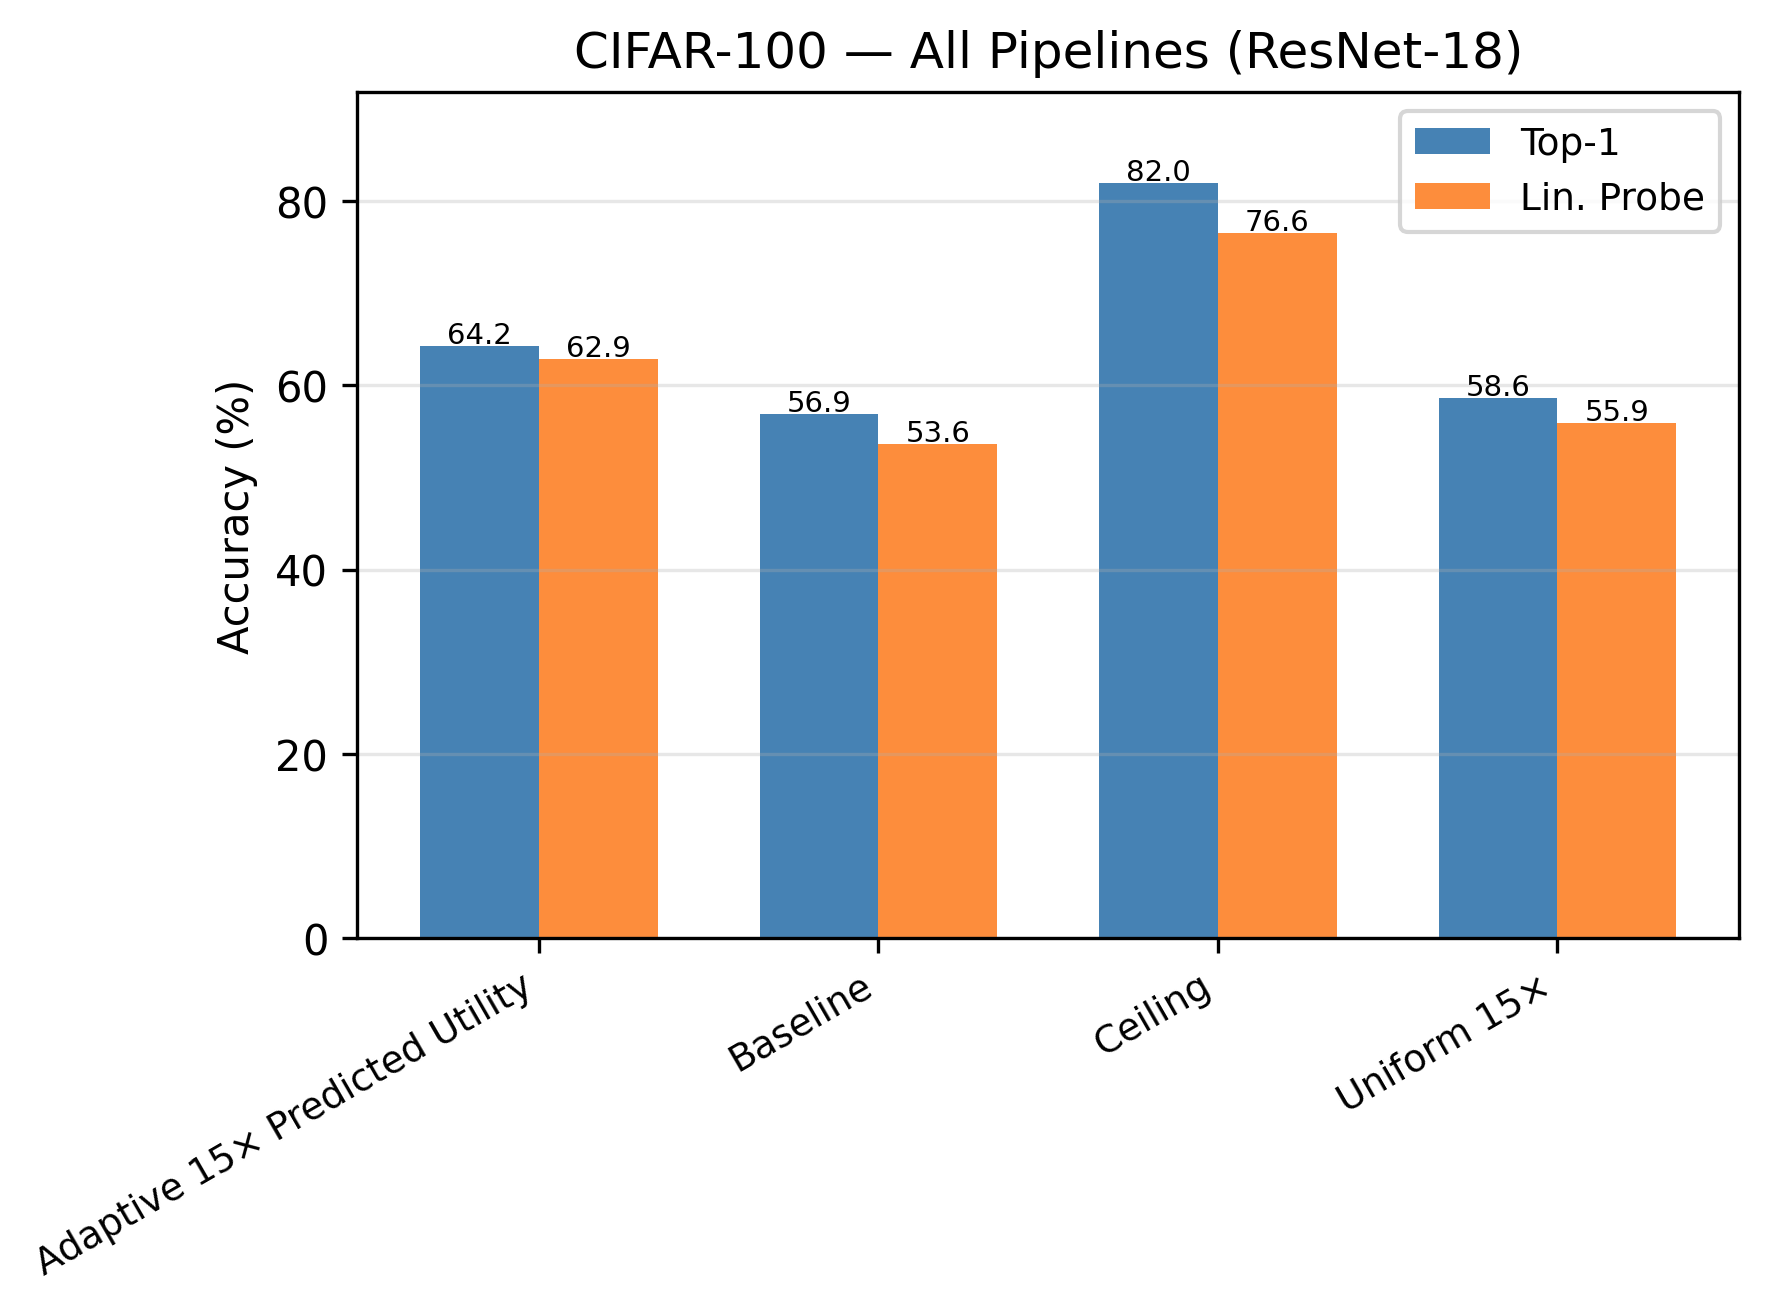

  ✓ fig9_cifar100_summary

SUMMARY TABLE (Tiny ImageNet + CIFAR-100, pre-SA)

  tiny_imagenet
  Pipeline                                      Arch                      Top-1
  --------------------------------------------- ---------------------- --------
  adaptive_15x_hard_class                       resnet18                 49.96%
  adaptive_15x_predicted_utility                mobilenet_v3_small       55.03%
  adaptive_15x_predicted_utility                resnet18                 49.29%
  adaptive_15x_uncertainty                      resnet18                 49.99%
  baseline                                      mobilenet_v3_small       50.31%
  baseline                                      resnet18                 49.44%
  ceiling                                       mobilenet_v3_small       71.69%
  ceiling                                       resnet18                 70.99%
  uniform_10x                                   resnet18                 49.98%
  uniform_15x             

In [11]:
if not RUN_CIFAR:
    print("Skipping CIFAR figures (RUN_CIFAR = False).")
else:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from IPython.display import display, Image as IPImage

    fig_dir = PROJECT_ROOT / "figures" / "stage2"
    fig_dir.mkdir(parents=True, exist_ok=True)

    def _load_runs(ds="tiny_imagenet"):
        idx = PROJECT_ROOT / "results" / ds / "results_index.json"
        if not idx.is_file(): return {}
        rows = json.loads(idx.read_text(encoding="utf-8"))
        return {(r["pipeline"], r["arch"]): r for r in rows}

    def _metrics(row):
        p = Path(row["path"]) / "metrics.json"
        return json.loads(p.read_text()) if p.is_file() else None

    def _save(name):
        png_path = fig_dir / f"{name}.png"
        plt.savefig(png_path, dpi=300, bbox_inches="tight")
        plt.savefig(fig_dir / f"{name}.pdf", bbox_inches="tight")
        plt.close()
        display(IPImage(filename=str(png_path)))
        print(f"  ✓ {name}")

    runs_cifar = _load_runs("cifar100")
    A = "resnet18"

    # Figs 1–7 (Tiny ImageNet) already generated in Phase 1 — skipped here.

    # ════════════════════════════════════════════════════════════
    # Fig 9 — CIFAR-100 summary bar
    # ════════════════════════════════════════════════════════════
    if runs_cifar:
        c_pipes = sorted(set(p for p, a in runs_cifar.keys() if a == A))
        c_labels = [p.replace("_", " ").replace("15x", "15×").title() for p in c_pipes]
        fig, ax = plt.subplots(figsize=(max(6, len(c_pipes)*1.2), 4.5))
        x = np.arange(len(c_pipes)); w = 0.35
        t1c, prc = [], []
        for p in c_pipes:
            k = (p, A)
            m = _metrics(runs_cifar[k])
            t1c.append(m["top1"]*100); prc.append(m["linear_probe_top1"]*100)
        b1 = ax.bar(x-w/2, t1c, w, label="Top-1", color="steelblue")
        b2 = ax.bar(x+w/2, prc, w, label="Lin. Probe", color="#fd8d3c")
        for bar, v in zip(b1, t1c): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.1f}", ha="center", fontsize=7)
        for bar, v in zip(b2, prc): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.1f}", ha="center", fontsize=7)
        ax.set_xticks(x); ax.set_xticklabels(c_labels, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Accuracy (%)"); ax.set_title("CIFAR-100 — All Pipelines (ResNet-18)")
        ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
        ax.set_ylim(0, max(max(t1c), max(prc))*1.12); plt.tight_layout()
        _save("fig9_cifar100_summary")
    else:
        print("  ⏭ fig9_cifar100_summary skipped (no CIFAR runs yet)")

    # ── Interim summary table ────────────────────────────────────
    print("\n" + "="*72)
    print("SUMMARY TABLE (Tiny ImageNet + CIFAR-100, pre-SA)")
    print("="*72)
    for ds_name in ["tiny_imagenet", "cifar100"]:
        idx_path = PROJECT_ROOT / "results" / ds_name / "results_index.json"
        if not idx_path.is_file(): continue
        rows = json.loads(idx_path.read_text(encoding="utf-8"))
        best = {(r["pipeline"], r["arch"]): r for r in rows}
        print(f"\n  {ds_name}")
        print(f"  {'Pipeline':<45} {'Arch':<22} {'Top-1':>8}")
        print(f"  {'-'*45} {'-'*22} {'-'*8}")
        for k2 in sorted(best.keys()):
            r = best[k2]
            print(f"  {r['pipeline']:<45} {r['arch']:<22} {r['top1']*100:>7.2f}%")
    print("="*72)
    print(f"\n✅ Fig 9 saved to {fig_dir}/")
    print("⏳ SA variants next …")

## IX. Synthetic-aware loss variants

Train SA-loss versions of Adaptive PU on Tiny ImageNet + CIFAR-100. These reuse the **same allocation CSVs** but pass the baseline checkpoint to enable `RealSyntheticMixDataset` + distance-weighted CE.

*(Uniform 15× SA dropped to save ~2.5 h — not needed for the CE-vs-SA ablation.)*

In [ ]:
if not RUN_SA_VARIANTS:
    print("Skipping synthetic-aware loss variants (RUN_SA_VARIANTS = False).")
else:
    # ── Tiny ImageNet R18: adaptive predicted_utility + SA loss ──
    print("─── Tiny: adaptive predicted_utility + SA loss ───")
    _cfg_t = "tiny_imagenet.yaml"
    _ds_t = "tiny_imagenet"
    _arch_t = "resnet18"

    # Need baseline checkpoint for SA loss centroids + CKA
    _bl_rd, _ = find_completed_run(_ds_t, "baseline", _arch_t)
    _r18_ckpt = Path(_bl_rd) / "best.pt" if _bl_rd else None

    _sa_csv_t = PROJECT_ROOT / "results" / _ds_t / "allocations" / "allocation_predicted_utility.csv"
    _sa_pipe_t = "adaptive_15x_predicted_utility_sa"

    if _r18_ckpt and _r18_ckpt.is_file() and _sa_csv_t.is_file():
        rd, m = recover_or_train(
            _ds_t, _sa_pipe_t, _arch_t,
            train_fn=lambda: orch.train_adaptive(
                _cfg_t, _arch_t, _sa_csv_t,
                name=_sa_pipe_t, baseline_ckpt_same_arch=_r18_ckpt,
            ),
            cfg_yaml=_cfg_t, baseline_ckpt=_r18_ckpt,
        )
    else:
        print("  ⚠ Missing baseline checkpoint or allocation CSV — run standard grid first")

    # ── (uniform_15x_sa dropped to save ~2.5 h — not needed for SA ablation) ──

    # ── CIFAR-100 R18: adaptive + SA loss ────────────────────────
    print("\n─── CIFAR: adaptive predicted_utility + SA loss ───")
    _cfg_c = "cifar100.yaml"
    _ds_c = "cifar100"
    _arch_c = "resnet18"

    _bl_rd_c, _ = find_completed_run(_ds_c, "baseline", _arch_c)
    _c_ckpt = Path(_bl_rd_c) / "best.pt" if _bl_rd_c else None

    _cfg_obj_c = orch.load_cfg(_cfg_c)
    _pol_c = _cfg_obj_c.scope.cifar_adaptive_policy
    _sa_csv_c = PROJECT_ROOT / "results" / _ds_c / "allocations" / f"allocation_{_pol_c}.csv"
    _sa_pipe_c = f"adaptive_15x_{_pol_c}_sa"

    if _c_ckpt and _c_ckpt.is_file() and _sa_csv_c.is_file():
        rd, m = recover_or_train(
            _ds_c, _sa_pipe_c, _arch_c,
            train_fn=lambda: orch.train_adaptive(
                _cfg_c, _arch_c, _sa_csv_c,
                name=_sa_pipe_c, baseline_ckpt_same_arch=_c_ckpt,
            ),
            cfg_yaml=_cfg_c, baseline_ckpt=_c_ckpt,
        )
    else:
        print("  ⚠ Missing baseline checkpoint or allocation CSV — run CIFAR grid first")

    # Re-aggregate both indexes to include _sa runs
    orch.aggregate_results_index("tiny_imagenet.yaml")
    orch.aggregate_results_index("cifar100.yaml")
    print("\n✅ SA variants complete. Results indexes updated.")

─── Tiny: adaptive predicted_utility + SA loss ───
  ▶ tiny_imagenet/adaptive_15x_predicted_utility_sa/resnet18 training …


/mnt/data/cv/src/stage2/orchestrator.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  frozen_ref.load_state_dict(torch.load(bpath, map_location=self.device))
/mnt/data/

Epoch 1/30  train_loss=4.0296 acc=0.1271  val_loss=3.4698 acc=0.3038


Train:  82%|████████▏ | 545/664 [08:07<01:50,  1.08it/s]

## X. SA ablation figures + final summary

Generates SA ablation plots (fig 8, fig 10) now that SA variants are complete, plus regenerates the CIFAR-100 summary bar (fig 9) to include the SA run. Prints the final combined summary table.

In [ ]:
if not RUN_SA_VARIANTS:
    print("Skipping SA ablation figures (RUN_SA_VARIANTS = False).")
else:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from IPython.display import display, Image as IPImage

    fig_dir = PROJECT_ROOT / "figures" / "stage2"
    fig_dir.mkdir(parents=True, exist_ok=True)

    def _load_runs(ds="tiny_imagenet"):
        idx = PROJECT_ROOT / "results" / ds / "results_index.json"
        if not idx.is_file(): return {}
        rows = json.loads(idx.read_text(encoding="utf-8"))
        return {(r["pipeline"], r["arch"]): r for r in rows}

    def _metrics(row):
        p = Path(row["path"]) / "metrics.json"
        return json.loads(p.read_text()) if p.is_file() else None

    def _save(name):
        png_path = fig_dir / f"{name}.png"
        plt.savefig(png_path, dpi=300, bbox_inches="tight")
        plt.savefig(fig_dir / f"{name}.pdf", bbox_inches="tight")
        plt.close()
        display(IPImage(filename=str(png_path)))
        print(f"  ✓ {name}")

    runs_tiny = _load_runs("tiny_imagenet")
    runs_cifar = _load_runs("cifar100")
    A = "resnet18"

    # ════════════════════════════════════════════════════════════
    # Fig 8 — SA loss ablation (Tiny ImageNet): CE vs SA
    # ════════════════════════════════════════════════════════════
    sa_pipes_t = [
        ("adaptive_15x_predicted_utility",    "Adapt. PU 15× (CE)"),
        ("adaptive_15x_predicted_utility_sa", "Adapt. PU 15× (SA)"),
    ]
    sa_available = [(p, l) for p, l in sa_pipes_t if (p, A) in runs_tiny]
    if len(sa_available) == 2:
        met_sa = ["Top-1", "Macro", "Worst-20", "ECE"]
        fig, ax = plt.subplots(figsize=(7, 4.5))
        x = np.arange(len(met_sa)); w = 0.3
        for i, (p, lbl) in enumerate(sa_available):
            m = _metrics(runs_tiny[(p, A)])
            vals = [m["top1"]*100, m["macro_acc"]*100, m["worst_k_acc"]*100, m["ece"]*100]
            ax.bar(x + i*w - w/2, vals, w, label=lbl)
            for j, v in enumerate(vals):
                ax.text(x[j] + i*w - w/2, v+0.3, f"{v:.1f}", ha="center", fontsize=6)
        ax.set_xticks(x); ax.set_xticklabels(met_sa)
        ax.set_ylabel("Value (% or ×100)"); ax.set_title("SA Loss Ablation — Tiny ImageNet (ResNet-18)")
        ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
        _save("fig8_sa_ablation_tiny")
    else:
        print("  ⏭ fig8_sa_ablation_tiny skipped (SA runs not yet available)")

    # ════════════════════════════════════════════════════════════
    # Fig 9 — CIFAR-100 summary bar (refresh to include SA run)
    # ════════════════════════════════════════════════════════════
    if runs_cifar:
        c_pipes = sorted(set(p for p, a in runs_cifar.keys() if a == A))
        c_labels = [p.replace("_", " ").replace("15x", "15×").title() for p in c_pipes]
        fig, ax = plt.subplots(figsize=(max(6, len(c_pipes)*1.2), 4.5))
        x = np.arange(len(c_pipes)); w = 0.35
        t1c, prc = [], []
        for p in c_pipes:
            k = (p, A)
            m = _metrics(runs_cifar[k])
            t1c.append(m["top1"]*100); prc.append(m["linear_probe_top1"]*100)
        b1 = ax.bar(x-w/2, t1c, w, label="Top-1", color="steelblue")
        b2 = ax.bar(x+w/2, prc, w, label="Lin. Probe", color="#fd8d3c")
        for bar, v in zip(b1, t1c): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.1f}", ha="center", fontsize=7)
        for bar, v in zip(b2, prc): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.1f}", ha="center", fontsize=7)
        ax.set_xticks(x); ax.set_xticklabels(c_labels, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Accuracy (%)"); ax.set_title("CIFAR-100 — All Pipelines (ResNet-18)")
        ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
        ax.set_ylim(0, max(max(t1c), max(prc))*1.12); plt.tight_layout()
        _save("fig9_cifar100_summary")

    # ════════════════════════════════════════════════════════════
    # Fig 10 — CIFAR-100 SA ablation
    # ════════════════════════════════════════════════════════════
    sa_pipes_c = [
        ("adaptive_15x_predicted_utility",    "Adapt. PU 15× (CE)"),
        ("adaptive_15x_predicted_utility_sa", "Adapt. PU 15× (SA)"),
    ]
    sa_avail_c = [(p, l) for p, l in sa_pipes_c if (p, A) in runs_cifar]
    if len(sa_avail_c) == 2:
        met_sa = ["Top-1", "Macro", "Worst-20", "ECE"]
        fig, ax = plt.subplots(figsize=(7, 4.5))
        x = np.arange(len(met_sa)); w = 0.3
        for i, (p, lbl) in enumerate(sa_avail_c):
            m = _metrics(runs_cifar[(p, A)])
            vals = [m["top1"]*100, m["macro_acc"]*100, m["worst_k_acc"]*100, m["ece"]*100]
            ax.bar(x + i*w - w/2, vals, w, label=lbl)
            for j, v in enumerate(vals):
                ax.text(x[j] + i*w - w/2, v+0.3, f"{v:.1f}", ha="center", fontsize=6)
        ax.set_xticks(x); ax.set_xticklabels(met_sa)
        ax.set_ylabel("Value (% or ×100)"); ax.set_title("SA Loss Ablation — CIFAR-100 (ResNet-18)")
        ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
        _save("fig10_sa_ablation_cifar")
    else:
        print("  ⏭ fig10_sa_ablation_cifar skipped (CIFAR SA runs not yet available)")

    # ── Final summary table ──────────────────────────────────────
    print("\n" + "="*72)
    print("FINAL SUMMARY TABLE (all datasets, including SA)")
    print("="*72)
    for ds_name in ["tiny_imagenet", "cifar100"]:
        idx_path = PROJECT_ROOT / "results" / ds_name / "results_index.json"
        if not idx_path.is_file(): continue
        rows = json.loads(idx_path.read_text(encoding="utf-8"))
        best = {(r["pipeline"], r["arch"]): r for r in rows}
        print(f"\n  {ds_name}")
        print(f"  {'Pipeline':<45} {'Arch':<22} {'Top-1':>8}")
        print(f"  {'-'*45} {'-'*22} {'-'*8}")
        for k2 in sorted(best.keys()):
            r = best[k2]
            print(f"  {r['pipeline']:<45} {r['arch']:<22} {r['top1']*100:>7.2f}%")
    print("="*72)
    print(f"\n✅ All figures complete → {fig_dir}/")

## XI. Submission checklist

- [ ] `results/` contains per-run `metrics.json`, `best.pt`, `training_curves.json`
- [ ] Figures under `figures/stage2/` (PNG + PDF)
- [ ] Summary table above matches expected numbers
- [ ] FID scores recorded in `results/*/fid_cache/fid_summary.json`
- [ ] *(optional)* SA variants trained (`RUN_SA_VARIANTS = True`)
- [ ] Export Stage 2 report PDF with numbers filled from `metrics.json` / `results_index.json`